Daisy Zhou
BINF 4008 - Final Project
Jupyter Notebook

In [2]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# import data from bigquery 

client = bigquery.Client(project='binf4008-project-dz')

query = """
SELECT *
FROM `binf4008-project-dz.mi_prediction.patient_cohort_features2`
"""

df = client.query(query).to_dataframe()
print(df.shape)
print(df.head())

/Users/daisyzhou/opt/anaconda3/envs/survival/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(33072, 106)
   subject_id  index_hadm_id     index_admittime     index_dischtime  \
0    10004235       24181354 2196-02-24 14:38:00 2196-03-04 14:02:00   
1    10025804       24064950 2184-12-02 20:44:00 2184-12-08 19:00:00   
2    10078115       28052678 2147-11-22 00:31:00 2148-01-23 15:00:00   
3    10113512       24931866 2121-11-28 18:00:00 2121-12-02 16:48:00   
4    10114932       21177187 2182-05-09 10:30:00 2182-05-14 15:10:00   

   followup_days  days_to_mi first_future_mi_date         dod  age gender  \
0            110        <NA>                  NaT         NaT   47      M   
1            144        <NA>                  NaT  2185-05-01   52      M   
2              0        <NA>                  NaT         NaT   50      M   
3             14        <NA>                  NaT         NaT   46      F   
4              0        <NA>                  NaT         NaT   53      M   

   ... ckd smoking obesity prior_stroke pvd  med_insulin  med_diuretic  \
0  ...   1       

## EDA, Data Preprocessing / Cleaning, Feature Engineering

In [4]:
df.columns.tolist()

['subject_id',
 'index_hadm_id',
 'index_admittime',
 'index_dischtime',
 'followup_days',
 'days_to_mi',
 'first_future_mi_date',
 'dod',
 'age',
 'gender',
 'race',
 'marital_status',
 'insurance',
 'admission_type',
 'discharge_location',
 'los_days',
 'num_prior_admissions',
 'num_prior_admissions_1yr',
 'days_since_last_admission',
 'num_prior_icu_stays',
 'heart_rate_mean',
 'heart_rate_max',
 'sbp_mean',
 'sbp_min',
 'dbp_mean',
 'dbp_min',
 'mbp_mean',
 'mbp_min',
 'resp_rate_mean',
 'resp_rate_max',
 'temperature_mean',
 'temperature_max',
 'spo2_mean',
 'spo2_min',
 'hematocrit_min',
 'hemoglobin_min',
 'platelets_min',
 'wbc_max',
 'bicarbonate_min',
 'bun_max',
 'calcium_min',
 'chloride_min',
 'creatinine_max',
 'glucose_max',
 'sodium_min',
 'potassium_max',
 'aniongap_max',
 'albumin_min',
 'bilirubin_total_max',
 'inr_max',
 'pt_max',
 'ptt_max',
 'd_dimer_max',
 'fibrinogen_min',
 'alt_max',
 'ast_max',
 'alp_max',
 'abs_neutrophils_max',
 'abs_lymphocytes_min',
 'abs_

In [5]:
def consolidate_race(race_str):
    if pd.isna(race_str):
        return 'Unknown'
    race_str = str(race_str).upper()
    
    if 'WHITE' in race_str:
        return 'White'
    elif 'BLACK' in race_str or 'AFRICAN' in race_str:
        return 'Black'
    elif 'HISPANIC' in race_str or 'LATINO' in race_str:
        return 'Hispanic'
    elif 'ASIAN' in race_str:
        return 'Asian'
    elif 'AMERICAN INDIAN' in race_str or 'ALASKA NATIVE' in race_str:
        return 'Native American'
    elif 'HAWAIIAN' in race_str or 'PACIFIC' in race_str:
        return 'Pacific Islander'
    elif ('UNKNOWN' in race_str or 'DECLINED' in race_str 
          or 'UNABLE' in race_str or 'OTHER' in race_str):
        return 'Unknown/Other'
    else:
        return 'Unknown/Other'

df['race'] = df['race'].apply(consolidate_race)
print(df['race'].value_counts())

race
White               21270
Unknown/Other        7144
Black                2429
Hispanic             1118
Asian                 989
Native American        69
Pacific Islander       53
Name: count, dtype: int64


In [ ]:
# Data Density / Missingness 

def assess_data_density(df, name="Dataset"):
    """
    Comprehensive missingness and data density assessment.
    """
    print(f"\n{'='*70}")
    print(f"Data Density Assessment: {name}")
    print(f"{'='*70}")
    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
    print(f"Total cells: {df.shape[0] * df.shape[1]:,}")
    
    # Overall missingness
    total_missing = df.isna().sum().sum()
    total_cells = df.shape[0] * df.shape[1]
    pct_missing = 100 * total_missing / total_cells
    print(f"Total missing values: {total_missing:,} ({pct_missing:.2f}%)")
    print(f"Total non-missing values: {total_cells - total_missing:,} ({100 - pct_missing:.2f}%)")
    
    # Per-column missingness summary
    missing_per_col = df.isna().sum()
    pct_per_col = 100 * missing_per_col / len(df)
    
    missingness_df = pd.DataFrame({
        "Column": missing_per_col.index,
        "N_Missing": missing_per_col.values,
        "Pct_Missing": pct_per_col.values,
        "N_Present": len(df) - missing_per_col.values,
        "Pct_Present": 100 - pct_per_col.values,
        "Dtype": df.dtypes.values,
    }).sort_values("Pct_Missing", ascending=False)
    
    # Categorize columns by missingness severity
    complete_cols = (pct_per_col == 0).sum()
    low_missing = ((pct_per_col > 0) & (pct_per_col <= 10)).sum()
    moderate_missing = ((pct_per_col > 10) & (pct_per_col <= 30)).sum()
    high_missing = ((pct_per_col > 30) & (pct_per_col <= 50)).sum()
    severe_missing = ((pct_per_col > 50) & (pct_per_col <= 75)).sum()
    very_severe = (pct_per_col > 75).sum()
    
    print(f"\nColumn-level missingness distribution:")
    print(f"Complete (0% missing):           {complete_cols:>4} columns")
    print(f"Low (>0-10% missing):            {low_missing:>4} columns")
    print(f"Moderate (10-30% missing):       {moderate_missing:>4} columns")
    print(f"High (30-50% missing):           {high_missing:>4} columns")
    print(f"Severe (50-75% missing):         {severe_missing:>4} columns")
    print(f"Very severe (>75% missing):      {very_severe:>4} columns")
    
    # Per-row completeness
    row_missing = df.isna().sum(axis=1)
    pct_row_complete = 100 * (1 - row_missing / df.shape[1])
    
    print(f"\nRow-level completeness:")
    print(f"Mean % features present per patient: {pct_row_complete.mean():.1f}%")
    print(f"Median % features present per patient: {pct_row_complete.median():.1f}%")
    print(f"Min % features present per patient: {pct_row_complete.min():.1f}%")
    print(f"Max % features present per patient: {pct_row_complete.max():.1f}%")
    
    return missingness_df

missingness_summary = assess_data_density(df, name="MIMIC-IV Patient Cohort")

# Show top 20 most-missing columns
print("\n" + "="*70)
print("Top 20 Columns by Missingness")
print("="*70)
display(missingness_summary.head(20))

# Show bottom 20 (most complete)
print("\n" + "="*70)
print("Top 20 Most Complete Columns")
print("="*70)
display(missingness_summary.tail(20).iloc[::-1])

# Summary by feature category (manual grouping)
print("\n" + "="*70)
print("Missingness by Feature Category")
print("="*70)

categories = {
    "Demographics": ["age", "gender", "race", "marital_status", "insurance", 
                     "admission_type", "discharge_location", "los_days"],
    "Healthcare utilization": ["num_prior_admissions", "num_prior_icu_stays", 
                               "days_since_last_admission"],
    "Vitals": ["heart_rate_mean", "heart_rate_max", "sbp_mean", "sbp_min", 
               "dbp_mean", "mbp_mean", "mbp_min", "resp_rate_mean", "resp_rate_max",
               "temperature_mean", "temperature_max", "spo2_mean", "spo2_min"],
    "Labs (CBC/Chem)": ["hematocrit_min", "wbc_max", "platelets_min", 
                        "bun_max", "creatinine_max", "glucose_max", "sodium_min",
                        "potassium_max", "bicarbonate_min"],
    "Blood Gas": ["lactate_max", "ph_min", "po2_min", "pco2_max", "pao2fio2ratio_min",
                  "baseexcess_min"],
    "Severity Scores": ["sofa_score", "sapsii"],
    "GCS": ["gcs_min", "gcs_motor", "gcs_verbal", "gcs_eyes"],
    "Anthropometrics": ["height", "weight_admit", "bmi_admit"],
}

cat_summary = []
for cat, cols in categories.items():
    available_cols = [c for c in cols if c in df.columns]
    if not available_cols:
        continue
    avg_missing = df[available_cols].isna().mean().mean() * 100
    cat_summary.append({
        "Category": cat,
        "N_Features": len(available_cols),
        "Avg_Pct_Missing": round(avg_missing, 1),
    })

cat_df = pd.DataFrame(cat_summary).sort_values("Avg_Pct_Missing")
display(cat_df)


Data Density Assessment: MIMIC-IV Patient Cohort
Shape: 33,072 rows × 106 columns
Total cells: 3,505,632
Total missing values: 503,849 (14.37%)
Total non-missing values: 3,001,783 (85.63%)

Column-level missingness distribution:
  Complete (0% missing):             33 columns
  Low (>0-10% missing):              45 columns
  Moderate (10-30% missing):          5 columns
  High (30-50% missing):              7 columns
  Severe (50-75% missing):           10 columns
  Very severe (>75% missing):         6 columns

Row-level completeness:
  Mean % features present per patient: 85.6%
  Median % features present per patient: 85.8%
  Min % features present per patient: 55.7%
  Max % features present per patient: 98.1%

Top 20 Columns by Missingness


,Column,N_Missing,Pct_Missing,N_Present,Pct_Present,Dtype
18,days_since_last_admission,33072,100.000000,0,0.000000,Int64
52,d_dimer_max,32768,99.080793,304,0.919207,float64
5,days_to_mi,32412,98.004354,660,1.995646,Int64
6,first_future_mi_date,32412,98.004354,660,1.995646,dbdate
60,bands_max,30058,90.886551,3014,9.113449,float64
7,dod,27089,81.909168,5983,18.090832,dbdate
53,fibrinogen_min,23480,70.996613,9592,29.003387,float64
47,albumin_min,21391,64.680092,11681,35.319908,float64
65,pao2fio2ratio_min,20072,60.691824,13000,39.308176,float64
48,bilirubin_total_max,18009,54.453919,15063,45.546081,float64



Top 20 Most Complete Columns


,Column,N_Missing,Pct_Missing,N_Present,Pct_Present,Dtype
105,renal_replacement_therapy,0,0.0,33072,100.0,Int64
104,vasopressor_use,0,0.0,33072,100.0,Int64
87,renal_disease,0,0.0,33072,100.0,Int64
86,diabetes_with_cc,0,0.0,33072,100.0,Int64
85,diabetes_without_cc,0,0.0,33072,100.0,Int64
84,mild_liver_disease,0,0.0,33072,100.0,Int64
83,peptic_ulcer_disease,0,0.0,33072,100.0,Int64
82,rheumatic_disease,0,0.0,33072,100.0,Int64
81,chronic_pulmonary_disease,0,0.0,33072,100.0,Int64
80,dementia,0,0.0,33072,100.0,Int64



Missingness by Feature Category


,Category,N_Features,Avg_Pct_Missing
5,Severity Scores,2,0.0
2,Vitals,13,0.5
6,GCS,4,0.7
3,Labs (CBC/Chem),9,1.2
0,Demographics,8,2.0
1,Healthcare utilization,3,33.3
7,Anthropometrics,3,36.9
4,Blood Gas,6,46.9


In [ ]:
# Check raw followup_days distribution
print(f"\nfollowup_days == 0: {(df['followup_days'] == 0).sum()}")
print(f"followup_days == 1: {(df['followup_days'] == 1).sum()}")
print(f"followup_days > 1: {(df['followup_days'] > 1).sum()}")
print(f"days_to_mi null: {df['days_to_mi'].isnull().sum()}")
print(f"days_to_mi not null: {df['days_to_mi'].notna().sum()}")

# Compute duration  
df['duration'] = df['days_to_mi'].fillna(df['followup_days'])
df['event'] = df['days_to_mi'].notna().astype(int)

print(f"\nBEFORE clip:")
print(f"duration == 0: {(df['duration'] == 0).sum()}")
print(f"duration < 0: {(df['duration'] < 0).sum()}")

# Clip to minimum 1 day instead of removing
# Patients with followup_days=0 were observed alive at discharge
# Setting to 1 means "survived at least 1 day post discharge"
df['duration'] = df['duration'].clip(lower=1)

print(f"\nAFTER clip:")
print(f"duration == 0: {(df['duration'] == 0).sum()}")
print(f"duration min: {df['duration'].min()}")
print(f"duration max: {df['duration'].max()}")

print(f"\n── Final Cohort Summary ────────────────────")
print(f"Total patients: {len(df)}")
print(f"MI events: {df['event'].sum()}")
print(f"Censored: {(df['event'] == 0).sum()}")
print(f"Event rate: {df['event'].mean()*100:.2f}%")
print(f"Median duration: {df['duration'].median():.0f} days")
print(f"Mean duration: {df['duration'].mean():.0f} days")
print(f"Min duration: {df['duration'].min():.0f} days")
print(f"Max duration: {df['duration'].max():.0f} days")


followup_days == 0:  18104
followup_days == 1:  143
followup_days > 1:   14825
days_to_mi null:     32412
days_to_mi not null: 660

BEFORE clip:
  duration == 0: 18106
  duration < 0:  0

AFTER clip:
  duration == 0: 0
  duration min:  1
  duration max:  5203

── Final Cohort Summary ────────────────────
Total patients:   33072
MI events:        660
Censored:         32412
Event rate:       2.00%
Median duration:  1 days
Mean duration:    332 days
Min duration:     1 days
Max duration:     5203 days


In [ ]:
print("Duration among patients with followup > 1 day:")
mask = df['followup_days'] > 1
print(f"N: {mask.sum()}")
print(f"Median: {df.loc[mask, 'duration'].median():.0f} days")
print(f"Mean: {df.loc[mask, 'duration'].mean():.0f} days")

print("\nDuration among MI patients:")
mask_mi = df['event'] == 1
print(f"N: {mask_mi.sum()}")
print(f"Median: {df.loc[mask_mi, 'duration'].median():.0f} days")
print(f"Mean: {df.loc[mask_mi, 'duration'].mean():.0f} days")

Duration among patients with followup > 1 day:
  N:      14825
  Median: 243 days
  Mean:   739 days

Duration among MI patients:
  N:      660
  Median: 822 days
  Mean:   1161 days


In [10]:
# Check what's happening with the zero/negative durations
print("=== BEFORE removing duration <= 0 ===")
print(f"Total patients: {len(df)}")
print(f"followup_days == 0: {(df['followup_days'] == 0).sum()}")
print(f"followup_days < 0:  {(df['followup_days'] < 0).sum()}")
print(f"followup_days null: {df['followup_days'].isnull().sum()}")
print(f"days_to_mi null:    {df['days_to_mi'].isnull().sum()}")
print(f"days_to_mi == 0:    {(df['days_to_mi'] == 0).sum()}")

# Check duration distribution
print(f"\nduration == 0:  {(df['duration'] == 0).sum()}")
print(f"duration < 0:   {(df['duration'] < 0).sum()}")
print(f"duration == 1:  {(df['duration'] == 1).sum()}")
print(f"duration 1-7:   {((df['duration'] >= 1) & (df['duration'] <= 7)).sum()}")
print(f"duration 7-30:  {((df['duration'] > 7) & (df['duration'] <= 30)).sum()}")
print(f"duration > 30:  {(df['duration'] > 30).sum()}")

=== BEFORE removing duration <= 0 ===
Total patients: 33072
followup_days == 0: 18104
followup_days < 0:  0
followup_days null: 0
days_to_mi null:    32412
days_to_mi == 0:    2

duration == 0:  0
duration < 0:   0
duration == 1:  18253
duration 1-7:   19203
duration 7-30:  1978
duration > 30:  11891


In [ ]:
# DEFINE FEATURE COLUMNS (EXCLUDE OUTCOMES AND IDENTIFIERS)

exclude_cols = [
    # Identifiers
    'subject_id', 'index_hadm_id',
    'index_admittime', 'index_dischtime',
    'first_future_mi_date', 'dod',

    # Survival outcome 
    'days_to_mi', 'followup_days',
    'duration', 'event',
]

feature_cols = [c for c in df.columns if c not in exclude_cols]
feature_df   = df[feature_cols]

print(f"Total columns:   {len(df.columns)}")
print(f"Excluded:        {len(exclude_cols)}")
print(f"Feature columns: {len(feature_cols)}")


Total columns:   108
Excluded:        10
Feature columns: 98


In [ ]:
#  Fix misclassified numeric columns 
force_numeric = [
    'temperature_min', 'temperature_max', 'temperature_mean',
    'height',
    'abs_neutrophils_min', 'abs_neutrophils_max',
    'abs_monocytes_min',   'abs_monocytes_max',
    'abs_lymphocytes_min', 'abs_lymphocytes_max'
]
for col in force_numeric:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Split into numeric and categorical 
feature_df   = df[feature_cols]
numeric_cols = feature_df.select_dtypes(
    include=['number', 'Int8', 'Int16', 'Int32', 'Int64',
             'UInt8', 'UInt16', 'UInt32', 'UInt64']
).columns.tolist()
cat_cols = feature_df.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print(f"Numeric:     {len(numeric_cols)}")
print(f"Categorical: {len(cat_cols)}")
print(f"Sum matches: {len(numeric_cols)+len(cat_cols) == len(feature_cols)}")

Numeric:     92
Categorical: 6
Sum matches: True


In [ ]:
# Compute skewness + assign imputation method 
DROP_THRESHOLD = 75
FLAG_THRESHOLD = 20

numeric_vals = feature_df[numeric_cols].astype(float)

skewness_df = pd.DataFrame({
    "feature": numeric_cols,
    "dtype": "numeric",
    "mean": numeric_vals.mean().values,
    "median": numeric_vals.median().values,
    "skewness": numeric_vals.skew().values,
    "pct_missing": (numeric_vals.isnull().sum() / len(feature_df) * 100).values
})

cat_df = pd.DataFrame({
    "feature": cat_cols,
    "dtype": "categorical",
    "mean": np.nan,
    "median": np.nan,
    "skewness": np.nan,
    "pct_missing": (feature_df[cat_cols].isnull().sum() / len(feature_df) * 100).values
})

full_df = pd.concat([skewness_df, cat_df], ignore_index=True)

def assign_method(row):
    pct = row["pct_missing"]
    skew = row["skewness"]
    dtype = row["dtype"]

    if pct > DROP_THRESHOLD:
        return "DROP"

    if dtype == "categorical":
        if pct == 0:
            return "NONE — complete"
        elif pct <= 5:
            return "MODE"
        else:
            return "FILL Unknown"

    if pct == 0:
        return "NONE — complete"

    if pct > FLAG_THRESHOLD:
        return "FLAG + MEDIAN"

    return "MEDIAN" if (pd.isna(skew) or abs(skew) > 1) else "MEAN"

full_df["imputation_method"] = full_df.apply(assign_method, axis=1)
full_df = full_df.sort_values("pct_missing", ascending=False)

pd.set_option("display.max_rows", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.2f}".format)

print(full_df[["feature", "dtype", "skewness", "pct_missing", "imputation_method"]].to_string(index=False))
print("\n" + "=" * 50)
print("SUMMARY BY IMPUTATION METHOD")
print("=" * 50)
print(full_df["imputation_method"].value_counts().to_string())

                   feature       dtype  skewness  pct_missing imputation_method
 days_since_last_admission     numeric       NaN       100.00              DROP
               d_dimer_max     numeric      2.23        99.08              DROP
                 bands_max     numeric      2.49        90.89              DROP
            fibrinogen_min     numeric      2.12        71.00     FLAG + MEDIAN
               albumin_min     numeric     -0.16        64.68     FLAG + MEDIAN
         pao2fio2ratio_min     numeric      1.31        60.69     FLAG + MEDIAN
       bilirubin_total_max     numeric      7.76        54.45     FLAG + MEDIAN
                   alp_max     numeric      8.10        54.18     FLAG + MEDIAN
                   alt_max     numeric     23.36        53.92     FLAG + MEDIAN
                 bmi_admit     numeric      1.55        53.69     FLAG + MEDIAN
                   ast_max     numeric     11.25        53.67     FLAG + MEDIAN
                    height     numeric  

In [ ]:
# Apply imputation 

# Step 1: DROP high missingness (>75%) 
drop_features = full_df[full_df["imputation_method"] == "DROP"]["feature"].tolist()
print(f"Dropping {len(drop_features)} columns:")
print(drop_features)
df = df.drop(columns=drop_features, errors="ignore")

# Step 2: CREATE FLAGS FIRST 
flag_features = full_df[full_df["imputation_method"] == "FLAG + MEDIAN"]["feature"].tolist()

print(f"\nFlagging {len(flag_features)} columns:")
print(flag_features)

for col in flag_features:
    flag_name = f"{col}_measured"
    if col in df.columns and flag_name not in df.columns:
        df[flag_name] = df[col].notna().astype(int)

# Step 3: IMPUTE flagged numeric columns 
for col in flag_features:
    if col in df.columns:
        df[col] = df[col].astype(float).fillna(df[col].astype(float).median())

# Step 4: IMPUTE remaining numeric
median_features = full_df[full_df["imputation_method"] == "MEDIAN"]["feature"].tolist()
mean_features = full_df[full_df["imputation_method"] == "MEAN"]["feature"].tolist()

print(f"\nImputing with median: {len(median_features)} columns")
print(f"Imputing with mean: {len(mean_features)} columns")

for col in median_features:
    if col in df.columns:
        df[col] = df[col].astype(float).fillna(df[col].astype(float).median())

for col in mean_features:
    if col in df.columns:
        df[col] = df[col].astype(float).fillna(df[col].astype(float).mean())

# Step 5: IMPUTE categorical 
mode_features = full_df[full_df["imputation_method"] == "MODE"]["feature"].tolist()
unknown_features = full_df[full_df["imputation_method"] == "FILL Unknown"]["feature"].tolist()

print(f"\nMode: {mode_features}")
print(f"Unknown: {unknown_features}")

for col in mode_features:
    if col in df.columns:
        mode_val = df[col].mode(dropna=True)
        df[col] = df[col].fillna(mode_val.iloc[0] if len(mode_val) > 0 else "Unknown")

for col in unknown_features:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

# Drop zero-variance flag columns 
flag_cols = [c for c in df.columns if c.endswith("_measured")]
zero_var_flags = [c for c in flag_cols if df[c].nunique(dropna=False) <= 1]

if zero_var_flags:
    print(f"\nDropping {len(zero_var_flags)} zero-variance flag columns:")
    print(zero_var_flags)
    df = df.drop(columns=zero_var_flags)
else:
    print(f"\nAll {len(flag_cols)} flag columns have proper variance")

feature_cols_remaining = [c for c in df.columns if c not in exclude_cols]
remaining = df[feature_cols_remaining].isnull().sum()
remaining = remaining[remaining > 0]

print("\n" + "=" * 50)
if len(remaining) == 0:
    print("No missing values remaining in feature columns!")
else:
    print("Still missing:")
    print(remaining)

print("=" * 50)
print(f"Dropped (high missingness): {len(drop_features)}")
print(f"Flag columns kept: {len([c for c in df.columns if c.endswith('_measured')])}")
print(f"Final shape: {df.shape}")
print(f"Patients: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

Dropping 3 columns:
['days_since_last_admission', 'd_dimer_max', 'bands_max']

Flagging 17 columns:
['fibrinogen_min', 'albumin_min', 'pao2fio2ratio_min', 'bilirubin_total_max', 'alp_max', 'alt_max', 'bmi_admit', 'ast_max', 'height', 'lactate_max', 'ph_min', 'pco2_max', 'baseexcess_min', 'po2_min', 'abs_neutrophils_max', 'abs_monocytes_max', 'abs_lymphocytes_min']

Imputing with median: 30 columns
Imputing with mean:   17 columns

Mode:    ['insurance', 'discharge_location']
Unknown: ['marital_status']

All 17 flag columns have proper variance

No missing values remaining in feature columns!
Dropped (high missingness):  3
Flag columns kept:           17
Final shape:                 (33072, 122)
Patients:                    33072
Total columns:               122


### Outliers

In [ ]:
# Get numeric columns (excluding outcomes)
exclude_cols = [
    'subject_id', 'index_hadm_id',
    'index_admittime', 'index_dischtime',
    'first_future_mi_date', 'dod',
    'days_to_mi', 'followup_days',
    'duration', 'event',
]

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

# Exclude binary columns from outlier diagnostics
numeric_cols = [
    c for c in numeric_cols
    if df[c].dropna().nunique() > 2
]

outlier_summary = []

for col in numeric_cols:
    series = df[col].dropna().astype(float)

    if series.std() == 0:
        continue

    z_scores = (series - series.mean()) / series.std()

    n_outliers_5sd  = (z_scores.abs() > 5).sum()
    n_outliers_10sd = (z_scores.abs() > 10).sum()
    max_abs_z       = z_scores.abs().max()

    if n_outliers_5sd > 0:
        outlier_summary.append({
            'feature': col,
            'max_abs_z': max_abs_z,
            'n_outliers_5sd': n_outliers_5sd,
            'n_outliers_10sd': n_outliers_10sd,
            'min': series.min(),
            'max': series.max(),
            'median': series.median(),
            'skewness': series.skew()
        })

outlier_df = pd.DataFrame(outlier_summary)

if len(outlier_df) > 0:
    outlier_df = outlier_df.sort_values('max_abs_z', ascending=False)
    print(outlier_df.to_string(index=False))
else:
    print("No numeric features with >5 SD outliers.")

                   feature  max_abs_z  n_outliers_5sd  n_outliers_10sd     min      max  median  skewness
              weight_admit     145.19               7                4    1.00  5864.00   79.00     93.52
                    weight     144.59               8                4    1.00  5864.00   79.65     92.37
       abs_lymphocytes_min     104.28              36               21    0.00   335.73    1.26     61.95
            baseexcess_min      92.29              83                1 -414.00    32.00   -2.00    -24.74
                   alt_max      91.87             167               75    1.00 61854.00   26.00     34.19
         abs_monocytes_max      85.22              64               23    0.00    57.55    0.53     40.53
               lactate_max      59.36             206               22    0.00    89.00    2.10     10.76
                   wbc_max      53.34              68               32    0.10   572.50   12.20     19.12
       abs_neutrophils_max      37.42         

In [ ]:
# for each flagged feature, look at the actual values

def inspect_feature(col):
    print(f"\n{'='*40}")
    print(f"Feature: {col}")
    print(f"{'='*40}")
    print(df[col].describe())
    print(f"\nTop 10 highest values:")
    print(df[col].nlargest(10).values)
    print(f"\nBottom 10 lowest values:")
    print(df[col].nsmallest(10).values)
    print(f"\nNumber of values >99.9th percentile:")
    p999 = df[col].quantile(0.999)
    print(f"  Threshold: {p999:.2f}")
    print(f"  Count: {(df[col] > p999).sum()}")

# Inspect each flagged column
for col in outlier_df['feature'].head(10):
    inspect_feature(col)


Feature: weight_admit
count   33072.00
mean       82.08
std        39.82
min         1.00
25%        67.00
50%        79.00
75%        93.00
max      5864.00
Name: weight_admit, dtype: float64

Top 10 highest values:
[5864.  1010.   886.   670.   310.   296.8  287.6  274.8  270.   268. ]

Bottom 10 lowest values:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Number of values >99.9th percentile:
  Threshold: 225.96
  Count: 34

Feature: weight
count   33072.00
mean       82.79
std        39.98
min         1.00
25%        67.30
50%        79.65
75%        94.31
max      5864.00
Name: weight, dtype: float64

Top 10 highest values:
[5864.  1010.   886.   670.   325.4  310.   296.8  288.4  274.8  270. ]

Bottom 10 lowest values:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Number of values >99.9th percentile:
  Threshold: 225.96
  Count: 34

Feature: abs_lymphocytes_min
count   33072.00
mean        1.45
std         3.21
min         0.00
25%         1.11
50%         1.26
75%         1.42
max       335.73
Name: abs_

In [ ]:
# Winsorization 
def winsorize(series, lower_pct=0.01, upper_pct=0.99):
    """Cap values at percentiles."""
    lower = series.quantile(lower_pct)
    upper = series.quantile(upper_pct)
    return series.clip(lower=lower, upper=upper)

# Apply only to numeric features (not flags or comorbidities)
features_to_winsorize = [
    c for c in numeric_cols 
    if not c.endswith('_measured')           # don't winsorize binary flags
    and df[c].nunique() > 10                  # don't winsorize binary comorbidities
]

print(f"Winsorizing {len(features_to_winsorize)} features at 1%-99%...")
for col in features_to_winsorize:
    df[col] = winsorize(df[col], 0.01, 0.99)

print("Done")

Winsorizing 55 features at 1%-99%...
Done


"We winsorized continuous features at the 1st and 99th percentiles to handle extreme outliers and data entry errors before scaling. This is standard practice for neural network-based survival models which are sensitive to outliers."

In [ ]:
# 0. Outcome / ID / leakage columns to exclude from features

exclude_from_features = [
    # IDs
    "subject_id",
    "index_hadm_id",

    # index timing
    "index_admittime",
    "index_dischtime",

    # outcome / censoring / leakage
    "followup_days",
    "days_to_mi",
    "first_future_mi_date",
    "dod",
    "duration",
    "event",
]

# 1. Drop prior-MI indicator if present

if "myocardial_infarct" in df.columns:
    print("Dropping myocardial_infarct column from predictors.")
    df = df.drop(columns=["myocardial_infarct"])

# 2. Recompute survival outcome

df["duration"] = df["days_to_mi"].fillna(df["followup_days"]).clip(lower=1)
df["event"] = df["days_to_mi"].notna().astype(int)

# 3. Drop any remaining artificial / redundant feature summaries

summary_cols_to_drop = [
    c for c in df.columns
    if c.endswith("_range") or c.endswith("_mid")
]

df = df.drop(columns=summary_cols_to_drop, errors="ignore")

print("Dropped artificial summary columns:", len(summary_cols_to_drop))
print(summary_cols_to_drop)

# 4. Consolidate remaining min/max/mean features if any remain

vital_bases = {
    "heart_rate",
    "sbp",
    "dbp",
    "mbp",
    "resp_rate",
    "temperature",
    "spo2",
}

vital_extremes_to_keep = {
    "heart_rate": "max",
    "sbp": "min",
    "dbp": "min",
    "mbp": "min",
    "resp_rate": "max",
    "temperature": "max",
    "spo2": "min",
}

keep_min_bases = {
    "hematocrit",
    "hemoglobin",
    "platelets",
    "bicarbonate",
    "calcium",
    "sodium",
    "albumin",
    "fibrinogen",
    "ph",
    "po2",
    "pao2fio2ratio",
    "baseexcess",
    "gcs",
}

keep_max_bases = {
    "wbc",
    "bun",
    "chloride",
    "creatinine",
    "glucose",
    "potassium",
    "aniongap",
    "bilirubin_total",
    "inr",
    "pt",
    "ptt",
    "d_dimer",
    "ck_cpk",
    "ck_mb",
    "alt",
    "ast",
    "alp",
    "abs_neutrophils",
    "abs_lymphocytes",
    "abs_monocytes",
    "bands",
    "troponin_t",
    "ck_mb_cardiac",
    "ntprobnp",
    "lactate",
    "pco2",
}

def get_base_and_suffix(col):
    match = re.match(r"(.+)_(min|max|mean)$", col)
    if match:
        return match.group(1), match.group(2)
    return col, None

features_to_drop_consolidation = []

for col in df.columns:
    if col in exclude_from_features:
        continue

    base, suffix = get_base_and_suffix(col)

    if suffix is None:
        continue

    if base in vital_bases:
        keep_suffixes = {"mean", vital_extremes_to_keep.get(base)}
        if suffix not in keep_suffixes:
            features_to_drop_consolidation.append(col)

    elif base in keep_min_bases:
        if suffix != "min":
            features_to_drop_consolidation.append(col)

    elif base in keep_max_bases:
        if suffix != "max":
            features_to_drop_consolidation.append(col)

    else:
        # Safety rule:
        # keep mean if present, otherwise keep max and drop min
        if suffix == "min":
            features_to_drop_consolidation.append(col)

df_consolidated = df.drop(
    columns=features_to_drop_consolidation,
    errors="ignore"
)

print("Dropped by min/max/mean consolidation:", len(features_to_drop_consolidation))
print(features_to_drop_consolidation)
print("Final consolidated shape:", df_consolidated.shape)

Dropped artificial summary columns: 0
[]
Dropped by min/max/mean consolidation: 2
['chloride_min', 'abs_lymphocytes_min']
Final consolidated shape: (33072, 120)


In [ ]:
# 5. Consolidate measured / missingness indicators

from collections import defaultdict
import re

df_consolidated = df_consolidated.copy()

measured_like_cols = [
    c for c in df_consolidated.columns
    if c.endswith("_measured") 
    or c.endswith("_missing") 
    or c.endswith("_was_missing")
]

def normalize_measured_base(col):
    col = re.sub(r"_(min|max|mean)_(measured|missing|was_missing)$", r"_measured", col)
    col = re.sub(r"_(missing|was_missing)$", r"_measured", col)
    return col

groups = defaultdict(list)

for c in measured_like_cols:
    groups[normalize_measured_base(c)].append(c)

new_measured = {}

for new_col, old_cols in groups.items():
    new_measured[new_col] = (
        df_consolidated[old_cols]
        .astype("float32")
        .max(axis=1)
    )

df_consolidated = df_consolidated.drop(columns=measured_like_cols, errors="ignore")

for new_col, values in new_measured.items():
    df_consolidated[new_col] = values

print("Number of original measured/missing columns:", len(measured_like_cols))
print("Number of consolidated measured columns:", len(new_measured))
print("Shape after measured consolidation:", df_consolidated.shape)

Number of original measured/missing columns: 17
Number of consolidated measured columns: 17
Shape after measured consolidation: (33072, 120)


In [ ]:

#  Drop deterministic / redundant clinical variables

manual_drop = [
    # deterministic transformation of SAPS-II
    "sapsii_prob",

    # comorbidity duplicate - ckd duplicates charlson renal_disease --> keep custom ckd which uses cleaner ICD logic
    "renal_disease", 

    # diabetes duplicates charlson diabetes_without_cc
    # diabetes_without_cc captures severity (complicated diabetes) therefore keep the general one and diabetes_with_cc
    "diabetes_without_cc",

    # charlson_pvd vs pvd - both capture peripheral vascular disease
    "charlson_pvd",

    # ── Cardiovascular pathophysiology overlap ──────────────
    # Heart failure and AF share underlying pathology with MI;
    # including them risks conflating prediction with etiology
    # of the same underlying coronary disease process
    "heart_failure",
    "af_or_flutter",

    # coagulation redundancy: INR and PT are almost identical
    "pt_max",          # keep inr_max

    # CBC redundancy: hematocrit and hemoglobin track together
    "hemoglobin_min",  # keep hematocrit_min

    # LFT redundancy
    "ast_max",         # keep alt_max

    # Weight redundancy (keep weight_admit)
    "weight",

    "dbp_mean", # keep mbp_mean - blood pressure redundancy

    # healthcare utilization redundacy
    "num_prior_admissions",
    "num_prior_admissions_1yr",

    # measured flag panel redundancies

]


manual_drop = [c for c in manual_drop if c in df_consolidated.columns]

df_consolidated = df_consolidated.drop(columns=manual_drop)

print("Manually dropped:", manual_drop)
print("Shape after manual redundancy drops:", df_consolidated.shape)

Manually dropped: ['renal_disease', 'diabetes_without_cc', 'charlson_pvd', 'heart_failure', 'af_or_flutter', 'pt_max', 'hemoglobin_min', 'ast_max', 'weight', 'dbp_mean', 'num_prior_admissions', 'num_prior_admissions_1yr']
Shape after manual redundancy drops: (33072, 108)


In [ ]:
# Correlation screening after consolidation

candidate_feature_cols = [
    c for c in df_consolidated.columns
    if c not in exclude_from_features
]

numeric_candidate_cols = (
    df_consolidated[candidate_feature_cols]
    .select_dtypes(include=["number", "bool"])
    .columns.tolist()
)

# Exclude binary variables from correlation screening
numeric_candidate_cols = [
    c for c in numeric_candidate_cols
    if df_consolidated[c].dropna().nunique() > 2
]

corr = df_consolidated[numeric_candidate_cols].astype(float).corr().abs()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

corr_threshold = 0.90

high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={
        "level_0": "feature_1",
        "level_1": "feature_2",
        0: "corr"
    })
    .sort_values("corr", ascending=False)
)

high_corr_pairs = high_corr_pairs[
    high_corr_pairs["corr"] >= corr_threshold
]

print("Highly correlated pairs:")
display(high_corr_pairs.head(50))

print("Number of high-correlation pairs:", len(high_corr_pairs))

Highly correlated pairs:


,feature_1,feature_2,corr


Number of high-correlation pairs: 0


In [23]:
# Check what _measured columns currently exist
measured_cols = [c for c in df_consolidated.columns if c.endswith('_measured')]
print("Current _measured columns:")
for c in sorted(measured_cols):
    print(f"  {c}")

Current _measured columns:
  abs_lymphocytes_measured
  abs_monocytes_measured
  abs_neutrophils_measured
  albumin_measured
  alp_measured
  alt_measured
  ast_measured
  baseexcess_measured
  bilirubin_total_measured
  bmi_admit_measured
  fibrinogen_measured
  height_measured
  lactate_measured
  pao2fio2ratio_measured
  pco2_measured
  ph_measured
  po2_measured


In [ ]:
# Build final feature matrix

feature_cols = [
    c for c in df_consolidated.columns
    if c not in exclude_from_features
]

cat_cols = (
    df_consolidated[feature_cols]
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

print("Final feature columns before encoding:", len(feature_cols))
print("Categorical columns:", cat_cols)

df_encoded = pd.get_dummies(
    df_consolidated,
    columns=cat_cols,
    drop_first=True,
    dtype=float
)

# remove non-feature columns from encoded dataframe
df_encoded = df_encoded.drop(
    columns=[c for c in exclude_from_features if c in df_encoded.columns],
    errors="ignore"
)

feature_cols_encoded = df_encoded.columns.tolist()

X = df_encoded.astype(float)

# y still comes from df_consolidated because duration/event were dropped from df_encoded
y_dur = df_consolidated["duration"].values
y_ev = df_consolidated["event"].values

print("Final encoded feature count:", X.shape[1])
print("Final X shape:", X.shape)

Final feature columns before encoding: 98
Categorical columns: ['gender', 'race', 'marital_status', 'insurance', 'admission_type', 'discharge_location']
Final encoded feature count: 127
Final X shape: (33072, 127)


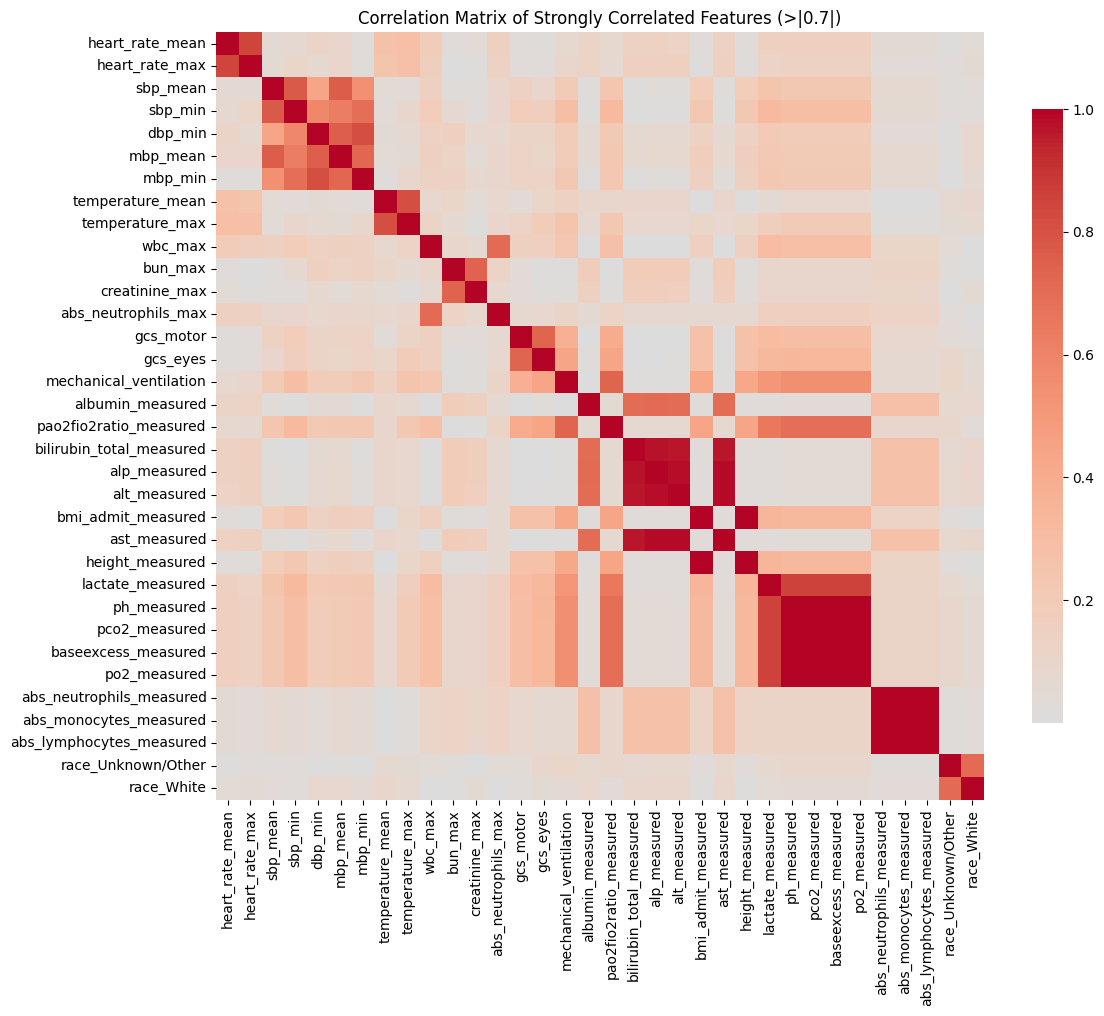

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use numeric features only
numeric_cols = X.select_dtypes(include=["number", "bool"]).columns

corr_matrix = X[numeric_cols].corr().abs()

# Keep only strong correlations
threshold = 0.7

high_corr_features = corr_matrix.columns[
    (corr_matrix > threshold).sum() > 1
]

corr_filtered = corr_matrix.loc[
    high_corr_features,
    high_corr_features
]

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_filtered,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Strongly Correlated Features (>|0.7|)")
plt.tight_layout()
plt.show()

In [ ]:
# Drop redundant panel-level _measured flags
# These are perfectly correlated within each lab panel

panel_measured_drop = [
    # ABG panel — all ~1.0 correlated (same blood draw)
    # Keep ONE as the panel indicator
    "pco2_measured",
    "po2_measured",
    "baseexcess_measured",
    # Keep ph_measured as the ABG panel indicator
    
    # CBC with differential panel — all ~1.0 correlated
    "abs_neutrophils_measured",
    "abs_lymphocytes_measured",
    # Keep abs_monocytes_measured as the CBC-diff panel indicator
    
    # Liver function tests — all ~0.95+ correlated
    "ast_measured",
    "alp_measured",
    "bilirubin_total_measured",
    # Keep alt_measured as the LFT panel indicator
    
    # Anthropometrics — bmi is computed from height & weight, so its
    # measurement flag is identical to height_measured
    "bmi_admit_measured",
    # Keep height_measured
]

panel_measured_drop = [c for c in panel_measured_drop if c in df_consolidated.columns]
df_consolidated = df_consolidated.drop(columns=panel_measured_drop)

print(f"Dropped {len(panel_measured_drop)} redundant panel _measured flags")
print(f"Shape after drops: {df_consolidated.shape}")

Dropped 9 redundant panel _measured flags
Shape after drops: (33072, 99)


In [27]:
# final correlation check
continuous_cols = [
    c for c in X.columns
    if X[c].dropna().nunique() > 2
]

corr_matrix = X[continuous_cols].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.90

high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={
        "level_0": "feature_1",
        "level_1": "feature_2",
        0: "corr"
    })
    .sort_values("corr", ascending=False)
)

high_corr_pairs = high_corr_pairs[
    high_corr_pairs["corr"] >= threshold
]

print("Number of high-correlation pairs:", len(high_corr_pairs))
display(high_corr_pairs.head(30))

Number of high-correlation pairs: 0


,feature_1,feature_2,corr


In [28]:
df_encoded = pd.get_dummies(
    df_consolidated,
    columns=cat_cols,
    drop_first=True,
    dtype=float
)

feature_cols_encoded = [
    c for c in df_encoded.columns
    if c not in exclude_from_features
]

X = df_encoded[feature_cols_encoded].astype(float)

In [29]:
# Save final modeling dataset
df_encoded.to_csv('patient_cohort_preprocessed.csv', index=False)

print("Saved patient_cohort_preprocessed.csv")
print(f"Shape: {df_encoded.shape}")

print("\nSurvival outcome check:")
print(
    f"duration — min: {df_encoded['duration'].min():.0f}, "
    f"max: {df_encoded['duration'].max():.0f}, "
    f"median: {df_encoded['duration'].median():.0f}"
)

print(
    f"event — 0: {(df_encoded['event']==0).sum()}, "
    f"1: {(df_encoded['event']==1).sum()}"
)

Saved patient_cohort_preprocessed.csv
Shape: (33072, 128)

Survival outcome check:
duration — min: 1, max: 5203, median: 1
event — 0: 32412, 1: 660


In [30]:
# Check remaining flag columns
flag_cols = [
    c for c in df_consolidated.columns
    if c.endswith('_measured')
]

print(f"Remaining flag columns: {len(flag_cols)}")
print(flag_cols)

# Check for any remaining zero-variance features
numeric_cols = df_consolidated.select_dtypes(
    include=['number']
).columns

zero_var = [
    c for c in numeric_cols
    if df_consolidated[c].std() == 0
]

print("\nRemaining zero-variance columns:")
print(zero_var if len(zero_var) > 0 else "None")

Remaining flag columns: 8
['fibrinogen_measured', 'albumin_measured', 'pao2fio2ratio_measured', 'alt_measured', 'height_measured', 'lactate_measured', 'ph_measured', 'abs_monocytes_measured']

Remaining zero-variance columns:
None


In [31]:
df_consolidated = df_consolidated.drop(
    columns=[
        "num_prior_admissions",
        "num_prior_admissions_1yr"
    ],
    errors="ignore"
)

In [ ]:
# Rebuild df_encoded and X after updating df_consolidated

# Feature columns before encoding
feature_cols = [
    c for c in df_consolidated.columns
    if c not in exclude_from_features
]

# Categorical columns to one-hot encode
cat_cols = (
    df_consolidated[feature_cols]
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

print("Feature columns before encoding:", len(feature_cols))
print("Categorical columns:", cat_cols)

# One-hot encode
df_encoded = pd.get_dummies(
    df_consolidated,
    columns=cat_cols,
    drop_first=True,
    dtype=float
)

# Remove outcome / ID / reference columns from final modeling dataframe
df_encoded = df_encoded.drop(
    columns=[c for c in exclude_from_features if c in df_encoded.columns],
    errors="ignore"
)

# Final feature matrix
X = df_encoded.astype(float)

# Outcome arrays come from df_consolidated
y_dur = df_consolidated["duration"].values
y_ev = df_consolidated["event"].values

print("Final encoded feature count:", X.shape[1])
print("Final X shape:", X.shape)
print("Remaining NaN in X:", X.isnull().sum().sum())

Feature columns before encoding: 89
Categorical columns: ['gender', 'race', 'marital_status', 'insurance', 'admission_type', 'discharge_location']
Final encoded feature count: 118
Final X shape: (33072, 118)
Remaining NaN in X: 0


In [ ]:
# Final dataset sanity check 

print(f"DataFrame shape:        {df_consolidated.shape}")
print(f"Patients:               {len(df_consolidated)}")
print(f"Total columns:          {len(df_consolidated.columns)}")

print(
    f"Duration range:         "
    f"{df_consolidated['duration'].min():.0f} "
    f"to {df_consolidated['duration'].max():.0f} days"
)

print(
    f"Duration median:        "
    f"{df_consolidated['duration'].median():.0f} days"
)

event_counts = df_consolidated["event"].value_counts().to_dict()

print(f"Event distribution:     {event_counts}")
print(
    f"Event rate:             "
    f"{df_consolidated['event'].mean()*100:.2f}%"
)


# Check for unexpected missing values


expected_missing_cols = {
    "days_to_mi",
    "first_future_mi_date",
    "dod"
}

nan_counts = df_consolidated.isnull().sum()
nan_counts = nan_counts[nan_counts > 0]

unexpected_nan = [
    c for c in nan_counts.index
    if c not in expected_missing_cols
]

if len(unexpected_nan) > 0:

    print("\nWARNING: Unexpected missing values detected:")
    print(nan_counts[unexpected_nan])

else:

    print("\nMissing values check passed.")
    print("Only expected outcome/reference fields contain NaN.")

DataFrame shape:        (33072, 99)
Patients:               33072
Total columns:          99
Duration range:         1 to 5203 days
Duration median:        1 days
Event distribution:     {0: 32412, 1: 660}
Event rate:             2.00%

Missing values check passed.
Only expected outcome/reference fields contain NaN.


In [ ]:
# Cohort Flow Diagram

print("="*70)
print("COHORT FLOW")
print("="*70)

print(f"Step 1: MIMIC-IV BigQuery cohort definition")
print(f"  - Inclusion: first ICU admission per patient, age ≥18, valid discharge")
print(f"  - Exclusion: prior MI history, MI at index, inpatient death")
print(f"  → Patients meeting cohort criteria: {len(df):,}")
print()

# Followup status breakdown
zero_followup = (df['followup_days'] == 0).sum()
positive_followup = (df['followup_days'] > 0).sum()
print(f"Step 2: Post-discharge follow-up status")
print(f"  - Patients with post-discharge observation (followup_days > 0): {positive_followup:,}")
print(f"  - Patients without post-discharge observation (followup_days = 0): {zero_followup:,}")
print(f"    → Treated as censored at day 1 (alive at discharge, no further info)")
print()

# After preprocessing
print(f"Step 3: Feature engineering & redundancy filtering")
print(f"  - Features dropped due to >75% missingness or redundancy")
print(f"  - All patients retained")
print()

print(f"FINAL ANALYTIC COHORT")
print(f"  → Patients: {len(df_consolidated):,}")
print(f"  → Features: {df_consolidated.shape[1]} columns")
print(f"  → MI events: {df_consolidated['event'].sum():,}")
print(f"  → Event rate: {df_consolidated['event'].mean()*100:.2f}%")
print()

# Follow-up summary — separate by event status for clarity
print(f"FOLLOW-UP TIME")
event_durations = df_consolidated.loc[df_consolidated['event']==1, 'duration']
censored_durations = df_consolidated.loc[df_consolidated['event']==0, 'duration']

print(f"  Patients with MI event (n={len(event_durations):,}):")
print(f"    Median time to MI: {event_durations.median():.0f} days")
print(f"    IQR: {event_durations.quantile(0.25):.0f} - {event_durations.quantile(0.75):.0f} days")
print()
print(f"  Censored patients (n={len(censored_durations):,}):")
print(f"    Median follow-up: {censored_durations.median():.0f} days")
print(f"    IQR: {censored_durations.quantile(0.25):.0f} - {censored_durations.quantile(0.75):.0f} days")
print(f"    Note: {(censored_durations==1).sum():,} ({100*(censored_durations==1).sum()/len(censored_durations):.1f}%) "
      f"had no post-discharge observation (followup_days=0)")

COHORT FLOW
Step 1: MIMIC-IV BigQuery cohort definition
  - Inclusion: first ICU admission per patient, age ≥18, valid discharge
  - Exclusion: prior MI history, MI at index, inpatient death
  → Patients meeting cohort criteria: 33,072

Step 2: Post-discharge follow-up status
  - Patients with post-discharge observation (followup_days > 0): 14,968
  - Patients without post-discharge observation (followup_days = 0): 18,104
    → Treated as censored at day 1 (alive at discharge, no further info)

Step 3: Feature engineering & redundancy filtering
  - Features dropped due to >75% missingness or redundancy
  - All patients retained

FINAL ANALYTIC COHORT
  → Patients: 33,072
  → Features: 99 columns
  → MI events: 660
  → Event rate: 2.00%

FOLLOW-UP TIME
  Patients with MI event (n=660):
    Median time to MI: 822 days
    IQR: 142 - 1818 days

  Censored patients (n=32,412):
    Median follow-up: 1 days
    IQR: 1 - 149 days
    Note: 18,247 (56.3%) had no post-discharge observation (fol

In [ ]:
# Table 1: Baseline Characteristics by Outcome

def make_table_1(df, event_col="event"):
    """Create baseline characteristics table stratified by outcome."""
    
    has_event = df[event_col] == 1
    no_event = df[event_col] == 0
    
    table_rows = []
    
    # Continuous variables - report mean (SD)
    continuous_features = [
        'age', 'los_days', 'sapsii', 'sofa_score', 
        'charlson_comorbidity_index', 'num_prior_icu_stays',
        'bun_max', 'creatinine_max', 'glucose_max'
    ]
    
    for feat in continuous_features:
        if feat not in df.columns:
            continue
        all_mean = df[feat].mean()
        all_std = df[feat].std()
        event_mean = df.loc[has_event, feat].mean()
        event_std = df.loc[has_event, feat].std()
        no_event_mean = df.loc[no_event, feat].mean()
        no_event_std = df.loc[no_event, feat].std()
        
        table_rows.append({
            "Variable": feat,
            "Type": "Continuous",
            "Overall (mean ± SD)": f"{all_mean:.1f} ± {all_std:.1f}",
            f"MI event (n={has_event.sum():,})": f"{event_mean:.1f} ± {event_std:.1f}",
            f"No MI (n={no_event.sum():,})": f"{no_event_mean:.1f} ± {no_event_std:.1f}",
        })
    
    # Binary/categorical - report N (%)
    binary_features = [
        'diabetes', 'diabetes_with_cc', 'ckd', 'hypertension',
        'smoking', 'obesity', 'hyperlipidemia', 'prior_stroke', 'pvd',
        'mechanical_ventilation', 'vasopressor_use', 'renal_replacement_therapy'
    ]
    
    for feat in binary_features:
        if feat not in df.columns:
            continue
        all_n = df[feat].sum()
        all_pct = 100 * all_n / len(df)
        event_n = df.loc[has_event, feat].sum()
        event_pct = 100 * event_n / has_event.sum()
        no_event_n = df.loc[no_event, feat].sum()
        no_event_pct = 100 * no_event_n / no_event.sum()
        
        table_rows.append({
            "Variable": feat,
            "Type": "Binary",
            "Overall (mean ± SD)": f"{all_n:,} ({all_pct:.1f}%)",
            f"MI event (n={has_event.sum():,})": f"{event_n:,} ({event_pct:.1f}%)",
            f"No MI (n={no_event.sum():,})": f"{no_event_n:,} ({no_event_pct:.1f}%)",
        })
    
    return pd.DataFrame(table_rows)


table_1 = make_table_1(df_consolidated)
print("Table 1: Baseline Characteristics by Outcome")
display(table_1)

# Save for report
table_1.to_csv("table_1_baseline_characteristics.csv", index=False)

Table 1: Baseline Characteristics by Outcome


,Variable,Type,Overall (mean ± SD),MI event (n=660),"No MI (n=32,412)"
0,age,Continuous,61.2 ± 18.0,68.2 ± 13.4,61.1 ± 18.0
1,los_days,Continuous,9.4 ± 9.4,10.6 ± 10.3,9.3 ± 9.3
2,sapsii,Continuous,31.2 ± 12.3,35.5 ± 11.1,31.1 ± 12.3
3,sofa_score,Continuous,3.5 ± 2.7,4.2 ± 2.8,3.4 ± 2.7
4,charlson_comorbidity_index,Continuous,3.7 ± 2.7,5.0 ± 2.4,3.7 ± 2.7
5,num_prior_icu_stays,Continuous,0.0 ± 0.1,0.0 ± 0.1,0.0 ± 0.1
6,bun_max,Continuous,21.7 ± 16.3,29.6 ± 21.4,21.5 ± 16.1
7,creatinine_max,Continuous,1.2 ± 1.0,1.6 ± 1.5,1.2 ± 1.0
8,glucose_max,Continuous,150.5 ± 67.7,166.1 ± 81.5,150.2 ± 67.3
9,diabetes,Binary,"7,401.0 (22.4%)",261.0 (39.5%),"7,140.0 (22.0%)"


Among MI events (n=660):
  Median time to MI: 822 days
  IQR: 142 - 1818 days
  Range: 1 - 4727 days

Among censored patients (n=32,412):
  Median follow-up: 1 days
  IQR: 1 - 149 days

MI events within 365 days (1 year): 231 (35.0% of all events)
MI events within 730 days (2 years): 315 (47.7% of all events)
MI events within 1825 days (5 years): 495 (75.0% of all events)


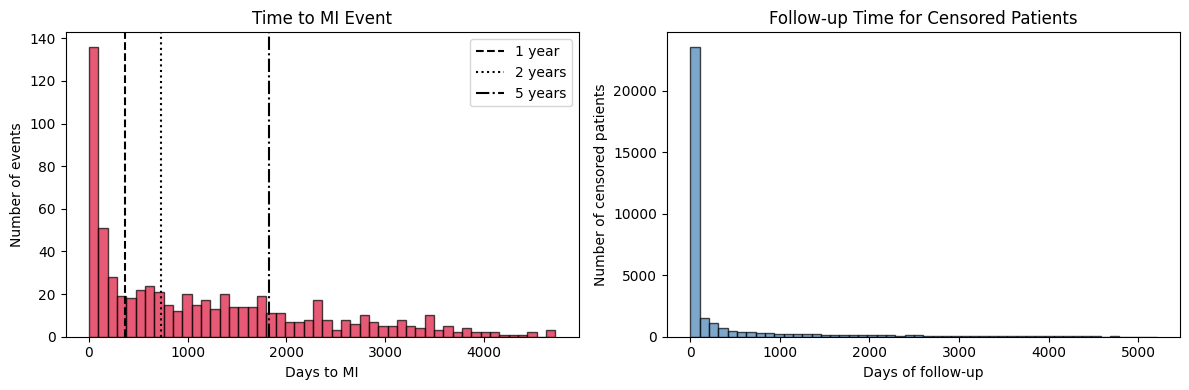

In [ ]:
# Event Timing Distribution

event_times = df_consolidated.loc[df_consolidated['event'] == 1, 'duration']
followup_times = df_consolidated.loc[df_consolidated['event'] == 0, 'duration']

print(f"Among MI events (n={len(event_times):,}):")
print(f"  Median time to MI: {event_times.median():.0f} days")
print(f"  IQR: {event_times.quantile(0.25):.0f} - {event_times.quantile(0.75):.0f} days")
print(f"  Range: {event_times.min():.0f} - {event_times.max():.0f} days")
print()
print(f"Among censored patients (n={len(followup_times):,}):")
print(f"  Median follow-up: {followup_times.median():.0f} days")
print(f"  IQR: {followup_times.quantile(0.25):.0f} - {followup_times.quantile(0.75):.0f} days")
print()

# Events within key time horizons
for horizon in [365, 730, 1825]:
    n_events_by_horizon = (event_times <= horizon).sum()
    pct_of_events = 100 * n_events_by_horizon / len(event_times)
    years = horizon // 365
    print(f"MI events within {horizon} days ({years} year{'s' if years > 1 else ''}): "
          f"{n_events_by_horizon:,} ({pct_of_events:.1f}% of all events)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(event_times, bins=50, color="crimson", alpha=0.7, edgecolor="black")
axes[0].axvline(365, color="black", linestyle="--", label="1 year")
axes[0].axvline(730, color="black", linestyle=":", label="2 years")
axes[0].axvline(1825, color="black", linestyle="-.", label="5 years")
axes[0].set_xlabel("Days to MI")
axes[0].set_ylabel("Number of events")
axes[0].set_title("Time to MI Event")
axes[0].legend()

axes[1].hist(followup_times, bins=50, color="steelblue", alpha=0.7, edgecolor="black")
axes[1].set_xlabel("Days of follow-up")
axes[1].set_ylabel("Number of censored patients")
axes[1].set_title("Follow-up Time for Censored Patients")

plt.tight_layout()
plt.show()

In [38]:
if 'diabetes' in df_consolidated.columns and 'diabetes_with_cc' in df_consolidated.columns:
    corr = df_consolidated['diabetes'].corr(df_consolidated['diabetes_with_cc'])
    print(f"Diabetes vs diabetes_with_cc correlation: {corr:.3f}")
else:
    print("One or both diabetes flags no longer in dataframe — skipping correlation check")

Diabetes vs diabetes_with_cc correlation: 0.446


## Modeling

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [41]:
# Recompute duration and event 
df_consolidated["duration"] = (
    df_consolidated["days_to_mi"]
    .fillna(df_consolidated["followup_days"])
    .clip(lower=1)
)

df_consolidated["event"] = (
    df_consolidated["days_to_mi"]
    .notna()
    .astype(int)
)

# Columns to exclude
exclude_from_features = [
    "subject_id",
    "index_hadm_id",
    "index_admittime",
    "index_dischtime",
    "first_future_mi_date",
    "dod",
    "days_to_mi",
    "followup_days",
    "duration",
    "event",
]

# Feature columns
feature_cols = [
    c for c in df_consolidated.columns
    if c not in exclude_from_features
]

print("Feature columns before encoding:", len(feature_cols))

# Identify categorical columns
cat_cols = (
    df_consolidated[feature_cols]
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

print("Categorical columns:", cat_cols)

# One-hot encode
df_encoded = pd.get_dummies(
    df_consolidated,
    columns=cat_cols,
    drop_first=True,
    dtype=float
)

feature_cols_encoded = [
    c for c in df_encoded.columns
    if c not in exclude_from_features
]

X = df_encoded[feature_cols_encoded].astype(float)
y_dur = df_consolidated["duration"].values
y_ev = df_consolidated["event"].values

print("Features after encoding:", len(feature_cols_encoded))
print("X shape:", X.shape)
print("Remaining NaN in X:", X.isna().sum().sum())

Feature columns before encoding: 89
Categorical columns: ['gender', 'race', 'marital_status', 'insurance', 'admission_type', 'discharge_location']
Features after encoding: 118
X shape: (33072, 118)
Remaining NaN in X: 0


In [42]:
from sklearn.model_selection import train_test_split
from sksurv.util import Surv
import numpy as np

# Create survival object
y_surv = Surv.from_arrays(
    event=y_ev.astype(bool),
    time=y_dur
)

# Train/test split (patient-level random split)
X_train, X_test, y_train_surv, y_test_surv = train_test_split(
    X,
    y_surv,
    test_size=0.2,
    random_state=42,
    stratify=y_ev  # keeps event rate balanced
)

print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)
print("Train event rate:", y_train_surv["event"].mean())
print("Test event rate: ", y_test_surv["event"].mean())

Train shape: (26457, 118)
Test shape:  (6615, 118)
Train event rate: 0.019956911214423403
Test event rate:  0.019954648526077097


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd

continuous_cols = []
binary_cols = []

for col in X_train.columns:
    vals = X_train[col].dropna().unique()
    vals_set = set(vals)

    if len(vals_set) <= 2 and vals_set.issubset({0, 1, 0.0, 1.0, True, False}):
        binary_cols.append(col)
    else:
        continuous_cols.append(col)

print(f"Continuous features: {len(continuous_cols)}")
print(f"Binary features:     {len(binary_cols)}")

imp_cont = SimpleImputer(strategy="median")
imp_bin = SimpleImputer(strategy="most_frequent")
scaler = StandardScaler()

# Continuous: impute first
X_train_cont_imputed = pd.DataFrame(
    imp_cont.fit_transform(X_train[continuous_cols]),
    columns=continuous_cols,
    index=X_train.index
)

X_test_cont_imputed = pd.DataFrame(
    imp_cont.transform(X_test[continuous_cols]),
    columns=continuous_cols,
    index=X_test.index
)

# Binary: impute only
X_train_bin_imputed = pd.DataFrame(
    imp_bin.fit_transform(X_train[binary_cols]),
    columns=binary_cols,
    index=X_train.index
).astype(float)

X_test_bin_imputed = pd.DataFrame(
    imp_bin.transform(X_test[binary_cols]),
    columns=binary_cols,
    index=X_test.index
).astype(float)

# Imputed but NOT scaled
# Use for RSF / Gradient Boosting

X_train_imputed = pd.concat(
    [X_train_cont_imputed, X_train_bin_imputed],
    axis=1
)[X_train.columns]

X_test_imputed = pd.concat(
    [X_test_cont_imputed, X_test_bin_imputed],
    axis=1
)[X_train.columns]


# Imputed AND scaled
# Use for Cox / Coxnet

X_train_cont_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_cont_imputed),
    columns=continuous_cols,
    index=X_train.index
)

X_test_cont_scaled = pd.DataFrame(
    scaler.transform(X_test_cont_imputed),
    columns=continuous_cols,
    index=X_test.index
)

X_train_scaled = pd.concat(
    [X_train_cont_scaled, X_train_bin_imputed],
    axis=1
)[X_train.columns]

X_test_scaled = pd.concat(
    [X_test_cont_scaled, X_test_bin_imputed],
    axis=1
)[X_train.columns]

print("\nImputed train shape:", X_train_imputed.shape)
print("Scaled train shape: ", X_train_scaled.shape)

print("Any NA in X_train_imputed?", X_train_imputed.isna().any().any())
print("Any NA in X_test_imputed? ", X_test_imputed.isna().any().any())
print("Any NA in X_train_scaled? ", X_train_scaled.isna().any().any())
print("Any NA in X_test_scaled?  ", X_test_scaled.isna().any().any())

Continuous features: 54
Binary features:     64

Imputed train shape: (26457, 118)
Scaled train shape:  (26457, 118)
Any NA in X_train_imputed? False
Any NA in X_test_imputed?  False
Any NA in X_train_scaled?  False
Any NA in X_test_scaled?   False


In [ ]:
# Standard Cox Proportional Hazards Model

from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

# Extract duration/event from sksurv survival objects
y_dur_train = y_train_surv["time"]
y_ev_train  = y_train_surv["event"]

y_dur_test = y_test_surv["time"]
y_ev_test  = y_test_surv["event"]

# Build train/test dataframes for lifelines
train_cox = X_train_scaled.copy()
train_cox["duration"] = y_dur_train
train_cox["event"] = y_ev_train.astype(int)

test_cox = X_test_scaled.copy()
test_cox["duration"] = y_dur_test
test_cox["event"] = y_ev_test.astype(int)

print("Fitting standard Cox Proportional Hazards model...")

coxph_final = CoxPHFitter(penalizer=0.01, l1_ratio=0.0)

coxph_final.fit(
    train_cox,
    duration_col="duration",
    event_col="event",
    show_progress=True
)

# Predict risk on test set
coxph_risk = coxph_final.predict_partial_hazard(test_cox)

coxnet_baseline_cindex = concordance_index(
    y_dur_test,
    -coxph_risk,
    y_ev_test
)

print(f"\n{'='*50}")
print(f"Cox PH C-index (test): {coxnet_baseline_cindex:.4f}")
print(f"{'='*50}")

# Summary with hazard ratios, confidence intervals, and p-values
coxph_summary = coxph_final.summary[[
    "coef", "exp(coef)",
    "exp(coef) lower 95%", "exp(coef) upper 95%",
    "p"
]].copy()
coxph_summary["abs_coef"] = coxph_summary["coef"].abs()
coxph_summary = coxph_summary.sort_values("abs_coef", ascending=False)

print("\nTop 20 features by absolute coefficient:")
print(coxph_summary.head(20).to_string())# 


Fitting standard Cox Proportional Hazards model...
Iteration 1: norm_delta = 4.79e-01, step_size = 0.9500, log_lik = -4218.64754, newton_decrement = 1.65e+02, seconds_since_start = 0.5
Iteration 2: norm_delta = 1.04e-01, step_size = 0.9500, log_lik = -4076.12924, newton_decrement = 9.46e+00, seconds_since_start = 0.9
Iteration 3: norm_delta = 1.23e-02, step_size = 0.9500, log_lik = -4066.33314, newton_decrement = 1.62e-01, seconds_since_start = 1.2
Iteration 4: norm_delta = 2.32e-04, step_size = 1.0000, log_lik = -4066.16954, newton_decrement = 5.85e-05, seconds_since_start = 1.6
Iteration 5: norm_delta = 9.47e-08, step_size = 1.0000, log_lik = -4066.16948, newton_decrement = 9.71e-12, seconds_since_start = 2.1
Convergence success after 5 iterations.

Cox PH C-index (test): 0.7049

Top 20 features by absolute coefficient:
                                        coef  exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%    p  abs_coef
covariate                                            

In [ ]:
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

# Extract duration/event from sksurv survival objects
y_dur_train = y_train_surv["time"]
y_ev_train  = y_train_surv["event"]

y_dur_test = y_test_surv["time"]
y_ev_test  = y_test_surv["event"]

print("Fitting Elastic Net Cox model...")

# Fit full regularization path
cph = CoxnetSurvivalAnalysis(
    l1_ratio=0.5,
    alpha_min_ratio=0.01,
    n_alphas=100,
    max_iter=100000,
    fit_baseline_model=True
)

cph.fit(X_train_scaled, y_train_surv)

print(f"Fitted regularization path with {len(cph.alphas_)} alpha values")

# Pick alpha 
selected_alpha = cph.alphas_[len(cph.alphas_) // 2]
print(f"Using alpha: {selected_alpha:.6f}")

#  Evaluate on test set 
coxnet_risk = cph.predict(X_test_scaled, alpha=selected_alpha)

cox_cindex = concordance_index_censored(
    y_ev_test.astype(bool),
    y_dur_test,
    coxnet_risk
)[0]

print(f"\n{'='*40}")
print(f"Elastic Net Cox C-index (test): {cox_cindex:.4f}")
print(f"{'='*40}")

# Build summary dataframe 
# Get coefficients at the selected alpha
alpha_idx = np.where(cph.alphas_ == selected_alpha)[0][0]
coefs = cph.coef_[:, alpha_idx]

summary = pd.DataFrame({
    "coef": coefs,
    "exp(coef)": np.exp(coefs)
}, index=X_train_scaled.columns)

summary["abs_coef"] = summary["coef"].abs()
summary = summary[summary["abs_coef"] > 1e-8].sort_values("abs_coef", ascending=False)

print(f"\nSelected {len(summary)} of {X_train_scaled.shape[1]} features")
print("\nTop 20 features by absolute coefficient:")
print(summary.head(20).to_string())

Fitting Elastic Net Cox model...
Fitted regularization path with 100 alpha values
Using alpha: 0.001957

Elastic Net Cox C-index (test): 0.7058

Selected 22 of 118 features

Top 20 features by absolute coefficient:
                            coef  exp(coef)  abs_coef
charlson_comorbidity_index  0.30       1.35      0.30
age                         0.23       1.26      0.23
bun_max                     0.11       1.12      0.11
bilirubin_total_max        -0.10       0.90      0.10
los_days                    0.09       1.09      0.09
med_diuretic                0.08       1.09      0.08
diabetes                    0.08       1.09      0.08
admission_type_EW EMER.    -0.06       0.94      0.06
hyperlipidemia              0.06       1.07      0.06
smoking                     0.06       1.06      0.06
hematocrit_min             -0.05       0.95      0.05
gcs_verbal                 -0.05       0.95      0.05
gender_M                    0.04       1.04      0.04
fibrinogen_min              0

In [ ]:
# Random Survival Forest Model

from sksurv.ensemble import RandomSurvivalForest
import numpy as np

# Use existing survival objects from train/test split
# y_train_surv and y_test_surv should already exist

# RSF uses imputed, unscaled features
X_train_rsf = X_train_imputed.astype(float)
X_test_rsf = X_test_imputed.astype(float)

print("Fitting Random Survival Forest...")

rsf = RandomSurvivalForest(
    n_estimators=300,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rsf.fit(X_train_rsf, y_train_surv)

rsf_cindex = rsf.score(X_test_rsf, y_test_surv)

print(f"\n{'='*40}")
print(f"RSF C-index (test): {rsf_cindex:.4f}")
print(f"{'='*40}")

Fitting Random Survival Forest...

RSF C-index (test): 0.7017


In [47]:
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd

X_pi_base = X_test_imputed

rng = np.random.default_rng(42)
n_subset = min(300, X_pi_base.shape[0])  # smaller = faster
idx = rng.choice(X_pi_base.shape[0], size=n_subset, replace=False)

X_test_sub = X_pi_base.iloc[idx]
y_test_sub = y_test_surv[idx]

print("Computing fast permutation importance...")

perm_imp = permutation_importance(
    rsf,
    X_test_sub,
    y_test_sub,
    n_repeats=1,
    random_state=42,
    n_jobs=1   # <- important fix
)

rsf_perm = (
    pd.DataFrame({
        "feature": X_test_sub.columns,
        "importance_mean": perm_imp.importances_mean,
        "importance_std": perm_imp.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
)

display(rsf_perm.head(20))

Computing fast permutation importance...


,feature,importance_mean,importance_std
48,bmi_admit,0.04,0.00
1,los_days,0.04,0.00
27,albumin_min,0.03,0.00
23,glucose_max,0.03,0.00
38,po2_min,0.03,0.00
21,calcium_min,0.03,0.00
37,ph_min,0.02,0.00
41,baseexcess_min,0.02,0.00
54,chronic_pulmonary_disease,0.02,0.00
36,lactate_max,0.02,0.00


In [48]:
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
import numpy as np

print("Fitting ELASTIC NET ...")

coxnet_baseline = CoxnetSurvivalAnalysis(
    l1_ratio=0.5,
    alpha_min_ratio=0.01,
    max_iter=100000,
    fit_baseline_model=True
)

coxnet_baseline.fit(X_train_scaled, y_train_surv)

# Baseline choice: use middle alpha from regularization path
baseline_alpha = coxnet_baseline.alphas_[len(coxnet_baseline.alphas_) // 2]

print("Baseline alpha used:", baseline_alpha)

# Predict risk on test set
coxnet_baseline_risk = coxnet_baseline.predict(
    X_test_scaled,
    alpha=baseline_alpha
)

# Test C-index
coxnet_baseline_cindex = concordance_index_censored(
    y_test_surv["event"],
    y_test_surv["time"],
    coxnet_baseline_risk
)[0]

print(f"\n{'='*40}")
print(f"Baseline Elastic Net Cox Test C-index: {coxnet_baseline_cindex:.4f}")
print(f"{'='*40}")

Fitting ELASTIC NET ...
Baseline alpha used: 0.0019573779729354424

Baseline Elastic Net Cox Test C-index: 0.7058


In [49]:
# Extract coefficients from baseline Elastic Net Cox model

# Get coefficients at the baseline alpha
coef_best = coxnet_baseline.coef_[:, list(coxnet_baseline.alphas_).index(baseline_alpha)]

penalized_cox_results = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coef": coef_best,
    "abs_coef": np.abs(coef_best),
})

penalized_cox_results["hazard_ratio"] = np.exp(penalized_cox_results["coef"])

penalized_cox_selected = (
    penalized_cox_results[penalized_cox_results["coef"] != 0]
    .sort_values("abs_coef", ascending=False)
)

print("\nTop selected features from Baseline Elastic Net Cox:")
print(penalized_cox_selected.head(20).to_string(index=False))
print(f"\nNumber of selected features: {len(penalized_cox_selected)}")


Top selected features from Baseline Elastic Net Cox:
                   feature  coef  abs_coef  hazard_ratio
charlson_comorbidity_index  0.30      0.30          1.35
                       age  0.23      0.23          1.26
                   bun_max  0.11      0.11          1.12
       bilirubin_total_max -0.10      0.10          0.90
                  los_days  0.09      0.09          1.09
              med_diuretic  0.08      0.08          1.09
                  diabetes  0.08      0.08          1.09
   admission_type_EW EMER. -0.06      0.06          0.94
            hyperlipidemia  0.06      0.06          1.07
                   smoking  0.06      0.06          1.06
            hematocrit_min -0.05      0.05          0.95
                gcs_verbal -0.05      0.05          0.95
                  gender_M  0.04      0.04          1.04
            fibrinogen_min  0.04      0.04          1.04
          diabetes_with_cc  0.03      0.03          1.03
            creatinine_max  0.03  

In [ ]:
# Gradient Boosted Survival Model

from sksurv.ensemble import GradientBoostingSurvivalAnalysis
import time

print("Fitting faster Gradient Boosted Survival model...")

start = time.time()

gbs = GradientBoostingSurvivalAnalysis(
    loss="coxph",
    learning_rate=0.05,
    n_estimators=100,      # reduced from 300
    max_depth=2,           # reduced from 3
    min_samples_split=30,
    min_samples_leaf=20,
    subsample=0.8,
    random_state=42
)

gbs.fit(X_train_imputed, y_train_surv)

gbs_risk = gbs.predict(X_test_imputed)

gbs_cindex = concordance_index_censored(
    y_test_surv["event"],
    y_test_surv["time"],
    gbs_risk
)[0]

print(f"Runtime minutes: {(time.time() - start) / 60:.2f}")
print(f"Gradient Boosted Survival C-index (test): {gbs_cindex:.4f}")

Fitting faster Gradient Boosted Survival model...
Runtime minutes: 12.77
Gradient Boosted Survival C-index (test): 0.6802


In [51]:
# Feature importance
importances = pd.DataFrame({
    "feature": X_train_imputed.columns,
    "importance": gbs.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 20 Gradient Boosting features:")
print(importances.head(20).to_string(index=False))


Top 20 Gradient Boosting features:
                   feature  importance
charlson_comorbidity_index        0.58
                   bun_max        0.23
          diabetes_with_cc        0.06
                   alt_max        0.05
                       age        0.02
                       ckd        0.02
                    sapsii        0.01
                  los_days        0.01
            creatinine_max        0.00
               glucose_max        0.00
   admission_type_EW EMER.        0.00
                  diabetes        0.00
          temperature_mean        0.00
            heart_rate_max        0.00
                 spo2_mean        0.00
                  spo2_min        0.00
            hematocrit_min        0.00
             platelets_min        0.00
                   wbc_max        0.00
           bicarbonate_min        0.00


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Penalized Cox PH",
        "Elastic Net Cox",
        "Random Survival Forest",
        "Gradient Boosted Survival"
    ],
    "Test C-index": [
        cox_cindex,
        coxnet_baseline_cindex,     
        rsf_cindex,
        gbs_cindex
    ]
})

results = results.sort_values("Test C-index", ascending=False)

display(results)

,Model,Test C-index
0,Penalized Cox PH,0.71
1,Elastic Net Cox,0.71
2,Random Survival Forest,0.70
3,Gradient Boosted Survival,0.68


## Hyperparameter Tuning

In [53]:
from sklearn.model_selection import KFold, ParameterGrid
from sksurv.metrics import concordance_index_censored
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
import numpy as np
import pandas as pd

N_SPLITS = 3

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

# Extract arrays from survival objects
y_dur_train = y_train_surv["time"]
y_ev_train  = y_train_surv["event"]

y_dur_test = y_test_surv["time"]
y_ev_test  = y_test_surv["event"]

coxph_grid = {
    "penalizer": [0.001, 0.01, 0.1, 1.0]
}

coxph_results = []

for params in ParameterGrid(coxph_grid):
    fold_scores = []

    for train_idx, val_idx in kf.split(X_train_scaled):
        X_tr = X_train_scaled.iloc[train_idx].copy()
        X_val = X_train_scaled.iloc[val_idx].copy()

        train_df = X_tr.copy()
        train_df["duration"] = y_dur_train[train_idx]
        train_df["event"] = y_ev_train[train_idx].astype(int)

        cph = CoxPHFitter(
            penalizer=params["penalizer"],
            l1_ratio=0.0
        )

        cph.fit(
            train_df,
            duration_col="duration",
            event_col="event",
            show_progress=False
        )

        val_risk = cph.predict_partial_hazard(X_val)

        val_cindex = concordance_index(
            y_dur_train[val_idx],
            -val_risk,
            y_ev_train[val_idx]
        )

        fold_scores.append(val_cindex)

    coxph_results.append({
        **params,
        "mean_cv_cindex": np.mean(fold_scores),
        "std_cv_cindex": np.std(fold_scores)
    })

coxph_results = pd.DataFrame(coxph_results).sort_values(
    "mean_cv_cindex",
    ascending=False
)

display(coxph_results)

best_coxph_params = coxph_results.iloc[0].to_dict()
print("Best Cox PH params:", best_coxph_params)

# Fit final tuned Cox PH
train_cox = X_train_scaled.copy()
train_cox["duration"] = y_dur_train
train_cox["event"] = y_ev_train.astype(int)

test_cox = X_test_scaled.copy()

coxph_final = CoxPHFitter(
    penalizer=best_coxph_params["penalizer"],
    l1_ratio=0.0
)

coxph_final.fit(
    train_cox,
    duration_col="duration",
    event_col="event",
    show_progress=False
)

coxph_risk = coxph_final.predict_partial_hazard(test_cox)

cox_cindex = concordance_index(
    y_dur_test,
    -coxph_risk,
    y_ev_test
)

print("Final tuned Cox PH test C-index:", cox_cindex)

/Users/daisyzhou/opt/anaconda3/envs/survival/lib/python3.11/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['insurance_No charge'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/Users/daisyzhou/opt/anaconda3/envs/survival/lib/python3.11/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['insurance_No charge'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/Users/daisyzhou/opt/anaconda3/envs/survival/lib/python3.11/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['insurance_No charge'] have very low 

,penalizer,mean_cv_cindex,std_cv_cindex
2,0.10,0.69,0.02
1,0.01,0.69,0.02
3,1.00,0.68,0.03
0,0.00,0.68,0.02


Best Cox PH params: {'penalizer': 0.1, 'mean_cv_cindex': 0.6915604096610326, 'std_cv_cindex': 0.02217643036704552}
Final tuned Cox PH test C-index: 0.6975692900548391


Running 3-fold CV for alpha selection...
Testing 10 alpha values across 3 folds
  Fold 1/3 complete
  Fold 2/3 complete
  Fold 3/3 complete

Best alpha:    0.000772
CV C-index:    0.4134 ± 0.3377

CV results across alphas:
 alpha  mean_cindex  std_cindex
  0.02         0.33        0.27
  0.01         0.40        0.33
  0.01         0.41        0.33
  0.00         0.41        0.33
  0.00         0.41        0.34
  0.00         0.41        0.34
  0.00         0.41        0.34
  0.00         0.41        0.34
  0.00         0.41        0.34
  0.00         0.41        0.34


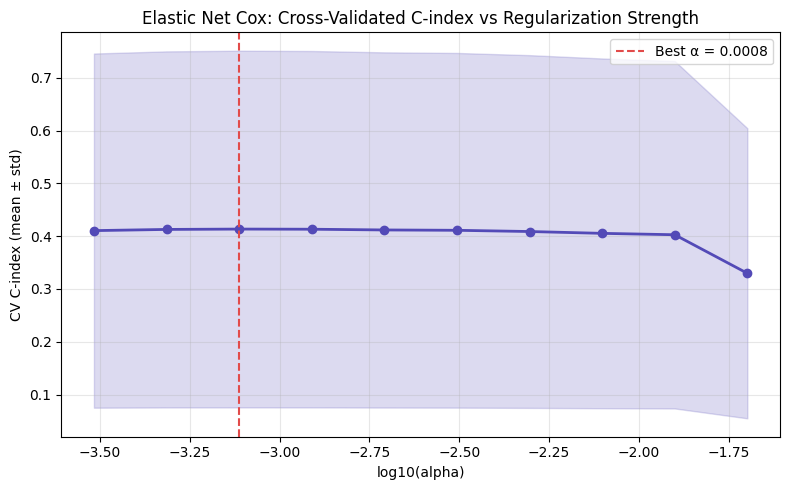

In [ ]:
# ELASTIC NET COX MODEL TUNING

from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sklearn.model_selection import KFold

# Cross-validation to select optimal alpha for Elastic Net Cox

print("Running 3-fold CV for alpha selection...")

# fit on full training data to get the alpha path 
path_model = CoxnetSurvivalAnalysis(
    l1_ratio=0.5,
    alpha_min_ratio=0.01,
    n_alphas=100,
    max_iter=100000,
    fit_baseline_model=False
)
path_model.fit(X_train_scaled, y_train_surv)

# Use a subset of alphas for CV 
cv_alphas = path_model.alphas_[::10]
print(f"Testing {len(cv_alphas)} alpha values across 3 folds")

# Run K-fold CV 
kf = KFold(n_splits=3, shuffle=True, random_state=42)
cv_scores = np.zeros((len(cv_alphas), 5))

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled)):
    X_fold_train = X_train_scaled.iloc[train_idx]
    X_fold_val   = X_train_scaled.iloc[val_idx]
    y_fold_train = y_train_surv[train_idx]
    y_fold_val   = y_train_surv[val_idx]

    fold_model = CoxnetSurvivalAnalysis(
        l1_ratio=0.5,
        alphas=cv_alphas,
        max_iter=100000,
        fit_baseline_model=False
    )
    fold_model.fit(X_fold_train, y_fold_train)

    for alpha_idx, alpha in enumerate(cv_alphas):
        fold_risk = fold_model.predict(X_fold_val, alpha=alpha)
        fold_cindex = concordance_index_censored(
            y_fold_val["event"].astype(bool),
            y_fold_val["time"],
            fold_risk
        )[0]
        cv_scores[alpha_idx, fold_idx] = fold_cindex

    print(f"  Fold {fold_idx + 1}/3 complete")

#  Summarize CV results 
mean_cv_scores = cv_scores.mean(axis=1)
std_cv_scores  = cv_scores.std(axis=1)

best_alpha_idx = mean_cv_scores.argmax()
best_alpha = cv_alphas[best_alpha_idx]
best_cindex = mean_cv_scores[best_alpha_idx]
best_std = std_cv_scores[best_alpha_idx]

print(f"\n{'='*50}")
print(f"Best alpha: {best_alpha:.6f}")
print(f"CV C-index: {best_cindex:.4f} ± {best_std:.4f}")
print(f"{'='*50}")

# CV results table 
cv_results = pd.DataFrame({
    "alpha": cv_alphas,
    "mean_cindex": mean_cv_scores,
    "std_cindex": std_cv_scores
})
print("\nCV results across alphas:")
print(cv_results.to_string(index=False))

# Plot CV curve 
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(np.log10(cv_alphas), mean_cv_scores, marker='o', color='#534AB7', linewidth=2)
ax.fill_between(
    np.log10(cv_alphas),
    mean_cv_scores - std_cv_scores,
    mean_cv_scores + std_cv_scores,
    alpha=0.2,
    color='#534AB7'
)
ax.axvline(np.log10(best_alpha), color='#E24B4A', linestyle='--', label=f'Best α = {best_alpha:.4f}')

ax.set_xlabel("log10(alpha)")
ax.set_ylabel("CV C-index (mean ± std)")
ax.set_title("Elastic Net Cox: Cross-Validated C-index vs Regularization Strength")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [55]:
selected_alpha = best_alpha  

coxnet_final = CoxnetSurvivalAnalysis(
    l1_ratio=0.5,
    alphas=[selected_alpha],
    max_iter=100000,
    fit_baseline_model=True
)
coxnet_final.fit(X_train_scaled, y_train_surv)

coxnet_risk = coxnet_final.predict(X_test_scaled)
cox_cindex = concordance_index_censored(
    y_ev_test.astype(bool),
    y_dur_test,
    coxnet_risk
)[0]

print(f"Test C-index at optimal alpha: {cox_cindex:.4f}")

Test C-index at optimal alpha: 0.6967


In [56]:
# Apply 1-SE rule
# Best alpha (max CV C-index)
best_alpha_max = cv_alphas[mean_cv_scores.argmax()]

# 1-SE alpha
best_cindex = mean_cv_scores.max()
best_std = std_cv_scores[mean_cv_scores.argmax()]
threshold = best_cindex - best_std
best_alpha_1se = cv_alphas[mean_cv_scores >= threshold].max()

print(f"Max-CV alpha:  {best_alpha_max:.6f}")
print(f"1-SE alpha:    {best_alpha_1se:.6f}")

# Fit both, compare on test set
for label, alpha in [("Max-CV", best_alpha_max), ("1-SE", best_alpha_1se)]:
    model = CoxnetSurvivalAnalysis(
        l1_ratio=0.5,
        alphas=[alpha],
        max_iter=100000,
        fit_baseline_model=True
    )
    model.fit(X_train_scaled, y_train_surv)
    
    risk = model.predict(X_test_scaled)
    cindex = concordance_index_censored(
        y_ev_test.astype(bool), y_dur_test, risk
    )[0]
    
    n_features = (np.abs(model.coef_.flatten()) > 1e-8).sum()
    
    print(f"\n{label} (alpha={alpha:.6f}):")
    print(f"  Test C-index:    {cindex:.4f}")
    print(f"  Features kept:   {n_features} / {X_train_scaled.shape[1]}")

Max-CV alpha:  0.000772
1-SE alpha:    0.020034

Max-CV (alpha=0.000772):
  Test C-index:    0.6967
  Features kept:   43 / 118

1-SE (alpha=0.020034):
  Test C-index:    0.5000
  Features kept:   0 / 118


/var/folders/1w/bhxr8mlj12765sccmbsksxnr0000gn/T/ipykernel_28718/634472424.py:22: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X_train_scaled, y_train_surv)


In [ ]:
# # ============================================================
# # 2. Elastic Net Cox tuning
# # ============================================================

# from sksurv.linear_model import CoxnetSurvivalAnalysis
# from sksurv.metrics import concordance_index_censored
# import numpy as np
# import pandas as pd
# import warnings

# def cindex_sksurv(y_true, risk_scores):
#     return concordance_index_censored(
#         y_true["event"],
#         y_true["time"],
#         risk_scores
#     )[0]

# coxnet_results = []

# l1_grid = [0.01, 0.1, 0.5]
# n_alpha_grid = 20

# for l1_ratio in l1_grid:
#     print(f"\nTuning l1_ratio={l1_ratio}")

#     base_model = CoxnetSurvivalAnalysis(
#         l1_ratio=l1_ratio,
#         alpha_min_ratio=0.01,
#         max_iter=100000,
#         fit_baseline_model=True
#     )

#     with warnings.catch_warnings():
#         warnings.simplefilter("ignore")
#         base_model.fit(X_train_scaled, y_train_surv)

#     alphas_all = base_model.alphas_

#     alpha_idx = np.linspace(
#         0,
#         len(alphas_all) - 1,
#         min(n_alpha_grid, len(alphas_all))
#     ).astype(int)

#     alphas = np.unique(alphas_all[alpha_idx])

#     for alpha in alphas:
#         fold_scores = []

#         for train_idx, val_idx in kf.split(X_train_scaled):
#             X_tr = X_train_scaled.iloc[train_idx]
#             X_val = X_train_scaled.iloc[val_idx]

#             y_tr = y_train_surv[train_idx]
#             y_val = y_train_surv[val_idx]

#             model = CoxnetSurvivalAnalysis(
#                 l1_ratio=l1_ratio,
#                 alphas=[float(alpha)],
#                 max_iter=100000,
#                 fit_baseline_model=True
#             )

#             try:
#                 with warnings.catch_warnings():
#                     warnings.simplefilter("ignore")
#                     model.fit(X_tr, y_tr)

#                 val_risk = model.predict(X_val)

#                 val_cindex = cindex_sksurv(y_val, val_risk)
#                 fold_scores.append(val_cindex)

#             except Exception as e:
#                 print(
#                     f"Failed: l1_ratio={l1_ratio}, "
#                     f"alpha={alpha:.6g}, error={e}"
#                 )
#                 fold_scores.append(np.nan)

#         valid_scores = [s for s in fold_scores if not np.isnan(s)]

#         if len(valid_scores) > 0:
#             coxnet_results.append({
#                 "l1_ratio": l1_ratio,
#                 "alpha": float(alpha),
#                 "mean_cv_cindex": np.mean(valid_scores),
#                 "std_cv_cindex": np.std(valid_scores),
#                 "n_valid_folds": len(valid_scores)
#             })

# coxnet_results = (
#     pd.DataFrame(coxnet_results)
#     .sort_values("mean_cv_cindex", ascending=False)
# )

# if coxnet_results.empty:
#     raise ValueError("All Coxnet CV runs failed. Check model fitting/data issues.")

# display(coxnet_results.head(10))

# best_coxnet = coxnet_results.iloc[0]

# print("Best Coxnet params:")
# print(best_coxnet)

# coxnet_final = CoxnetSurvivalAnalysis(
#     l1_ratio=float(best_coxnet["l1_ratio"]),
#     alphas=[float(best_coxnet["alpha"])],
#     max_iter=100000,
#     fit_baseline_model=True
# )

# with warnings.catch_warnings():
#     warnings.simplefilter("ignore")
#     coxnet_final.fit(X_train_scaled, y_train_surv)

# coxnet_risk = coxnet_final.predict(X_test_scaled)

# coxnet_cindex = cindex_sksurv(
#     y_test_surv,
#     coxnet_risk
# )

# print(f"Final Elastic Net Cox test C-index: {coxnet_cindex:.4f}")


Tuning l1_ratio=0.01

Tuning l1_ratio=0.1

Tuning l1_ratio=0.5


,l1_ratio,alpha,mean_cv_cindex,std_cv_cindex,n_valid_folds
14,0.10,0.01,0.70,0.03,3
15,0.10,0.01,0.70,0.02,3
36,0.50,0.00,0.70,0.02,3
16,0.10,0.01,0.69,0.02,3
13,0.10,0.01,0.69,0.03,3
37,0.50,0.00,0.69,0.03,3
17,0.10,0.01,0.69,0.03,3
35,0.50,0.00,0.69,0.02,3
12,0.10,0.00,0.69,0.03,3
34,0.50,0.00,0.69,0.02,3


Best Coxnet params:
l1_ratio         0.10
alpha            0.01
mean_cv_cindex   0.70
std_cv_cindex    0.03
n_valid_folds    3.00
Name: 14, dtype: float64
Final Elastic Net Cox test C-index: 0.7070


In [ ]:
# RSF tuning
from sksurv.ensemble import RandomSurvivalForest
from sklearn.model_selection import ParameterGrid, KFold
import time

#  define 3-fold CV  across all models
N_SPLITS = 3
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

rsf_grid = {
    "n_estimators": [100,200],
    "min_samples_leaf": [10, 20],
    "max_features": ["sqrt"]
}

rsf_results = []

start = time.time()

for params in ParameterGrid(rsf_grid):

    fold_scores = []

    for train_idx, val_idx in kf.split(X_train_imputed):

        X_tr = X_train_imputed.iloc[train_idx]
        X_val = X_train_imputed.iloc[val_idx]

        y_tr = y_train_surv[train_idx]
        y_val = y_train_surv[val_idx]

        model = RandomSurvivalForest(
            n_estimators=params["n_estimators"],
            min_samples_leaf=params["min_samples_leaf"],
            max_features=params["max_features"],
            min_samples_split=20,
            n_jobs=-1,
            random_state=42
        )

        model.fit(X_tr, y_tr)

        score = model.score(X_val, y_val)

        fold_scores.append(score)

    rsf_results.append({
        **params,
        "mean_cv_cindex": np.mean(fold_scores),
        "std_cv_cindex": np.std(fold_scores)
    })

rsf_results = pd.DataFrame(rsf_results).sort_values(
    "mean_cv_cindex",
    ascending=False
)

display(rsf_results)

best_rsf = rsf_results.iloc[0]

print("Best RSF params:")
print(best_rsf)

print(
    "Runtime minutes:",
    round((time.time() - start) / 60, 2)
)

,max_features,min_samples_leaf,n_estimators,mean_cv_cindex,std_cv_cindex
3,sqrt,20,200,0.67,0.01
2,sqrt,20,100,0.67,0.01
0,sqrt,10,100,0.66,0.01
1,sqrt,10,200,0.66,0.00


Best RSF params:
max_features        sqrt
min_samples_leaf      20
n_estimators         200
mean_cv_cindex      0.67
std_cv_cindex       0.01
Name: 3, dtype: object
Runtime minutes: 17.25


In [58]:
rsf_final = RandomSurvivalForest(
    n_estimators=int(best_rsf["n_estimators"]),
    min_samples_leaf=int(best_rsf["min_samples_leaf"]),
    max_features=best_rsf["max_features"],
    min_samples_split=20,
    n_jobs=-1,
    random_state=42
)

rsf_final.fit(X_train_imputed, y_train_surv)

rsf_risk_cindex = rsf_final.score(X_test_imputed, y_test_surv)

print(f"Final tuned RSF test C-index: {rsf_risk_cindex:.4f}")

Final tuned RSF test C-index: 0.7022


In [73]:
rsf_risk = rsf_final.predict(
    X_test_imputed
)

In [ ]:
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sklearn.model_selection import ParameterGrid
from sksurv.metrics import concordance_index_censored

N_SPLITS = 3
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)


def cindex_sksurv(y_true, risk_scores):
    return concordance_index_censored(
        y_true["event"],
        y_true["time"],
        risk_scores
    )[0]

gbs_grid = {
    "n_estimators": [100, 150],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
    "min_samples_leaf": [10, 20]
}

grid_list = list(ParameterGrid(gbs_grid))
total_fits = len(grid_list) * N_SPLITS

gbs_results = []
fit_counter = 0
start_time = time.time()

for combo_i, params in enumerate(grid_list, start=1):
    fold_scores = []

    print(f"\nParameter combo {combo_i}/{len(grid_list)}: {params}", flush=True)

    for fold_i, (train_idx, val_idx) in enumerate(kf.split(X_train_imputed), start=1):
        fit_counter += 1

        elapsed_min = (time.time() - start_time) / 60
        avg_time_per_fit = elapsed_min / fit_counter
        remaining_fits = total_fits - fit_counter
        est_remaining_min = avg_time_per_fit * remaining_fits

        print(
            f"  Fit {fit_counter}/{total_fits} | "
            f"Fold {fold_i}/{N_SPLITS} | "
            f"Elapsed: {elapsed_min:.1f} min | "
            f"Est. remaining: {est_remaining_min:.1f} min",
            flush=True
        )

        X_tr = X_train_imputed.iloc[train_idx]
        X_val = X_train_imputed.iloc[val_idx]

        y_tr = y_train_surv[train_idx]
        y_val = y_train_surv[val_idx]

        model = GradientBoostingSurvivalAnalysis(
            loss="coxph",
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            min_samples_split=20,
            subsample=0.8,
            random_state=42
        )

        model.fit(X_tr, y_tr)

        val_risk = model.predict(X_val)
        val_cindex = cindex_sksurv(y_val, val_risk)

        print(f"    Fold C-index: {val_cindex:.4f}", flush=True)

        fold_scores.append(val_cindex)

    combo_result = {
        **params,
        "mean_cv_cindex": np.mean(fold_scores),
        "std_cv_cindex": np.std(fold_scores)
    }

    gbs_results.append(combo_result)

    print(
        f"  Combo mean CV C-index: {combo_result['mean_cv_cindex']:.4f}",
        flush=True
    )

gbs_results = pd.DataFrame(gbs_results).sort_values(
    "mean_cv_cindex",
    ascending=False
)

display(gbs_results)

best_gbs = gbs_results.iloc[0]
print("Best GBS params:")
print(best_gbs)

gbs_final = GradientBoostingSurvivalAnalysis(
    loss="coxph",
    n_estimators=int(best_gbs["n_estimators"]),
    learning_rate=float(best_gbs["learning_rate"]),
    max_depth=int(best_gbs["max_depth"]),
    min_samples_leaf=int(best_gbs["min_samples_leaf"]),
    min_samples_split=20,
    subsample=0.8,
    random_state=42
)

print("\nFitting final GBS model on full training set...", flush=True)

gbs_final.fit(X_train_imputed, y_train_surv)

gbs_risk = gbs_final.predict(X_test_imputed)

gbs_cindex = cindex_sksurv(y_test_surv, gbs_risk)

print("Final Gradient Boosted Survival test C-index:", gbs_cindex)
print("Total runtime minutes:", round((time.time() - start_time) / 60, 2))


Parameter combo 1/16: {'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 10, 'n_estimators': 100}
  Fit 1/48 | Fold 1/3 | Elapsed: 0.0 min | Est. remaining: 0.0 min
    Fold C-index: 0.6699
  Fit 2/48 | Fold 2/3 | Elapsed: 6.7 min | Est. remaining: 153.0 min
    Fold C-index: 0.6805
  Fit 3/48 | Fold 3/3 | Elapsed: 13.0 min | Est. remaining: 195.2 min
    Fold C-index: 0.6665
  Combo mean CV C-index: 0.6723

Parameter combo 2/16: {'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 10, 'n_estimators': 150}
  Fit 4/48 | Fold 1/3 | Elapsed: 19.2 min | Est. remaining: 211.6 min
    Fold C-index: 0.6724
  Fit 5/48 | Fold 2/3 | Elapsed: 28.0 min | Est. remaining: 240.6 min
    Fold C-index: 0.6810
  Fit 6/48 | Fold 3/3 | Elapsed: 36.6 min | Est. remaining: 256.5 min
    Fold C-index: 0.6681
  Combo mean CV C-index: 0.6738

Parameter combo 3/16: {'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 20, 'n_estimators': 100}
  Fit 7/48 | Fold 1/3 | Elapsed: 45.0 min | Es

,learning_rate,max_depth,min_samples_leaf,n_estimators,mean_cv_cindex,std_cv_cindex
13,0.10,3,10,150,0.68,0.00
15,0.10,3,20,150,0.68,0.00
11,0.10,2,20,150,0.67,0.00
3,0.05,2,20,150,0.67,0.01
1,0.05,2,10,150,0.67,0.01
9,0.10,2,10,150,0.67,0.00
12,0.10,3,10,100,0.67,0.00
4,0.05,3,10,100,0.67,0.00
7,0.05,3,20,150,0.67,0.00
14,0.10,3,20,100,0.67,0.00


Best GBS params:
learning_rate        0.10
max_depth            3.00
min_samples_leaf    10.00
n_estimators       150.00
mean_cv_cindex       0.68
std_cv_cindex        0.00
Name: 13, dtype: float64

Fitting final GBS model on full training set...
Final Gradient Boosted Survival test C-index: 0.6855392520132405
Total runtime minutes: 362.0


In [ ]:
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sklearn.model_selection import KFold
import numpy as np
import time

print("Running 3-fold CV for GBM...")
start = time.time()

gbm_params = {
    "loss": "coxph",
    "learning_rate": 0.10,
    "n_estimators": 150,
    "max_depth": 3,
    "min_samples_split": 20,
    "min_samples_leaf": 20,
    "subsample": 0.8,
    "random_state": 42,
}

kf = KFold(n_splits=3, shuffle=True, random_state=42)
fold_scores = []

for fold_num, (train_idx, val_idx) in enumerate(kf.split(X_train_imputed), start=1):
    fold_start = time.time()
    
    X_tr = X_train_imputed.iloc[train_idx]
    X_val = X_train_imputed.iloc[val_idx]
    y_tr = y_train_surv[train_idx]
    y_val = y_train_surv[val_idx]
    
    model = GradientBoostingSurvivalAnalysis(**gbm_params)
    model.fit(X_tr, y_tr)
    score = model.score(X_val, y_val)

    
    fold_scores.append(score)
    
    print(f"  Fold {fold_num}: C-index = {score:.4f} ({(time.time()-fold_start)/60:.1f} min)")

cv_mean = np.mean(fold_scores)
cv_std = np.std(fold_scores)

print(f"\nGBM Train CV C-index: {cv_mean:.4f} ± {cv_std:.4f}")
print(f"Total runtime: {(time.time() - start) / 60:.2f} min")

Running 3-fold CV for GBM...
  Fold 1: C-index = 0.6743 (8.5 min)
  Fold 2: C-index = 0.6776 (8.7 min)
  Fold 3: C-index = 0.6740 (8.6 min)

GBM Train CV C-index: 0.6753 ± 0.0016
Total runtime: 25.74 min


In [62]:
# Final fit on full training set + test C-index
print("\nFitting final GBM on full training set...")
final_start = time.time()

gbs_final = GradientBoostingSurvivalAnalysis(**gbm_params)
gbs_final.fit(X_train_imputed, y_train_surv)

gbs_risk = gbs_final.predict(X_test_imputed)

gbs_cindex = concordance_index_censored(
    y_test_surv["event"].astype(bool),
    y_test_surv["time"],
    gbs_risk
)[0]

print(f"GBM Test C-index: {gbs_cindex:.4f}")
print(f"Final fit runtime: {(time.time() - final_start) / 60:.2f} min")

# Summary
print(f"\n{'='*60}")
print(f"GBM Train CV C-index: {cv_mean:.4f} ± {cv_std:.4f}")
print(f"GBM Test C-index:     {gbs_cindex:.4f}")
print(f"{'='*60}")


Fitting final GBM on full training set...
GBM Test C-index: 0.6860
Final fit runtime: 20.57 min

GBM Train CV C-index: 0.6753 ± 0.0016
GBM Test C-index:     0.6860


## MODEL EVALUATION

### Hazard Ratios + 95% CI

In [63]:
# Hazard ratios from final Cox PH model
cox_summary = coxph_final.summary.copy()

hr_df = cox_summary[[
    "coef",
    "exp(coef)",
    "exp(coef) lower 95%",
    "exp(coef) upper 95%",
    "p"
]].copy()

hr_df = hr_df.rename(columns={
    "exp(coef)": "HR",
    "exp(coef) lower 95%": "HR_lower_95",
    "exp(coef) upper 95%": "HR_upper_95"
})

hr_df["abs_coef"] = hr_df["coef"].abs()

top_hr = hr_df.sort_values("abs_coef", ascending=False).head(15)

display(top_hr)

,coef,HR,HR_lower_95,HR_upper_95,p,abs_coef
covariate,,,,,,
insurance_No charge,-0.25,0.78,0.07,9.27,0.84,0.25
race_Native American,0.24,1.28,0.61,2.66,0.52,0.24
diabetes_with_cc,0.21,1.23,1.06,1.43,0.01,0.21
ckd,0.15,1.16,1.04,1.29,0.01,0.15
num_prior_icu_stays,-0.13,0.88,0.59,1.30,0.51,0.13
pvd,0.12,1.13,0.90,1.43,0.29,0.12
renal_replacement_therapy,0.11,1.12,0.91,1.38,0.29,0.11
race_Pacific Islander,0.11,1.11,0.45,2.74,0.82,0.11
discharge_location_ASSISTED LIVING,-0.10,0.91,0.26,3.21,0.88,0.10


In [ ]:
# Filter to  meaningful predictors
meaningful = hr_df[
    (hr_df['p'] < 0.05) &              
    (hr_df['HR_lower_95'] > 0.5) &     
    (hr_df['HR_upper_95'] < 2.0)       
].sort_values('abs_coef', ascending=False)

print("Statistically significant predictors with stable CIs:")
print(meaningful)

Statistically significant predictors with stable CIs:
                            coef   HR  HR_lower_95  HR_upper_95    p  abs_coef
covariate                                                                     
diabetes_with_cc            0.21 1.23         1.06         1.43 0.01      0.21
ckd                         0.15 1.16         1.04         1.29 0.01      0.15
diabetes                    0.09 1.09         1.01         1.19 0.03      0.09
charlson_comorbidity_index  0.06 1.06         1.02         1.10 0.00      0.06
age                         0.05 1.05         1.01         1.09 0.01      0.05
bun_max                     0.04 1.04         1.01         1.08 0.02      0.04


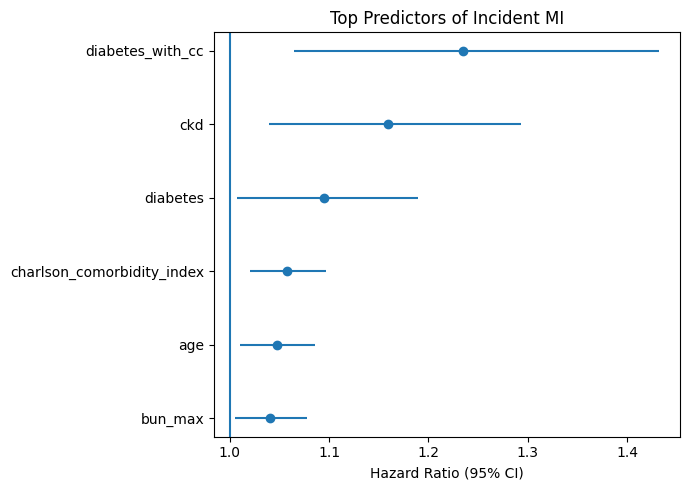

In [ ]:
# filter variables
features_to_plot = [
    "diabetes_with_cc",
    "ckd",
    "diabetes",
    "charlson_comorbidity_index",
    "age",
    "bun_max"
]

plot_df = hr_df.loc[features_to_plot].copy()

# sort by effect size
plot_df = plot_df.sort_values(
    "HR",
    ascending=True
)

# generate plot
plt.figure(figsize=(7,5))

plt.errorbar(
    plot_df["HR"],
    plot_df.index,
    xerr=[
        plot_df["HR"] - plot_df["HR_lower_95"],
        plot_df["HR_upper_95"] - plot_df["HR"]
    ],
    fmt="o"
)

plt.axvline(1)

plt.xlabel("Hazard Ratio (95% CI)")
plt.title("Top Predictors of Incident MI")

plt.tight_layout()
plt.show()

### Hazard Ratios from Elastic Net Model

In [67]:
coef = coxnet_final.coef_.ravel()

elastic_net_results = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coef": coef
})

elastic_net_results["HR"] = np.exp(elastic_net_results["coef"])

elastic_net_selected = (
    elastic_net_results[elastic_net_results["coef"] != 0]
    .sort_values("coef", ascending=False)
)

display(elastic_net_selected.head(10))

,feature,coef,HR
51,charlson_comorbidity_index,0.26,1.30
0,age,0.26,1.29
83,gender_M,0.23,1.26
58,diabetes_with_cc,0.22,1.25
71,med_diuretic,0.17,1.19
103,admission_type_OBSERVATION ADMIT,0.17,1.18
63,diabetes,0.16,1.18
1,los_days,0.11,1.12
20,bun_max,0.10,1.11
105,admission_type_URGENT,0.08,1.08


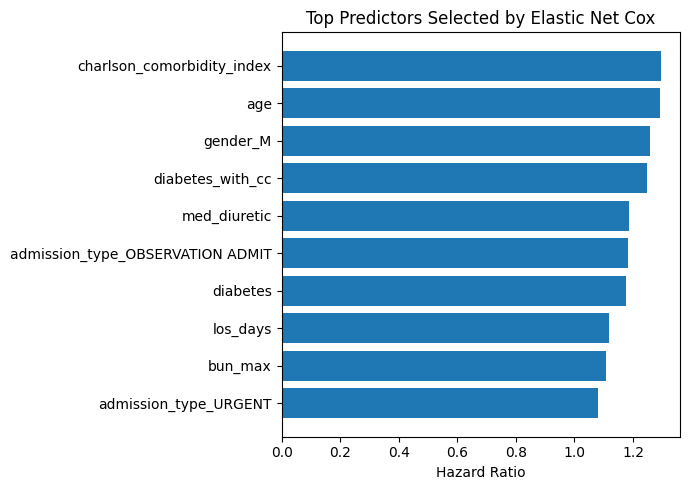

In [68]:
# coefficient / hazard ratio bar plot for regularized model

top_features = elastic_net_selected.head(10)

plt.figure(figsize=(7,5))

plt.barh(
    top_features["feature"],
    top_features["HR"]
)

plt.gca().invert_yaxis()

plt.xlabel("Hazard Ratio")
plt.title("Top Predictors Selected by Elastic Net Cox")

plt.tight_layout()
plt.show()

In [69]:
from sksurv.metrics import concordance_index_censored

def get_cindex(y_true, risk_scores):
    return concordance_index_censored(
        y_true["event"],
        y_true["time"],
        risk_scores
    )[0]

In [70]:
from sklearn.utils import resample
import numpy as np
from sksurv.metrics import concordance_index_censored

def bootstrap_cindex(y_test, risk_scores, n_bootstrap=1000):
    # Convert risk scores to numpy array if it's a pandas Series
    if hasattr(risk_scores, 'values'):
        risk_scores = risk_scores.values
    risk_scores = np.asarray(risk_scores)
    
    cindices = []
    n = len(risk_scores)
    
    for _ in range(n_bootstrap):
        idx = resample(np.arange(n))
        y_boot = y_test[idx]
        risk_boot = risk_scores[idx]
        
        c = concordance_index_censored(
            y_boot["event"].astype(bool), 
            y_boot["time"], 
            risk_boot
        )[0]
        cindices.append(c)
    
    return np.percentile(cindices, [2.5, 97.5])

# Run for both models
cox_ci = bootstrap_cindex(y_test_surv, coxph_risk)
en_ci = bootstrap_cindex(y_test_surv, coxnet_risk)  # double-check this is your Elastic Net risk

print(f"Cox PH C-index: 0.7070 (95% CI: {cox_ci[0]:.3f}-{cox_ci[1]:.3f})")
print(f"Elastic Net Cox C-index: 0.7082 (95% CI: {en_ci[0]:.3f}-{en_ci[1]:.3f})")

Cox PH C-index: 0.7070 (95% CI: 0.644-0.750)
Elastic Net Cox C-index: 0.7082 (95% CI: 0.645-0.745)


In [74]:
# coxph_risk = coxph_final.predict_partial_hazard(
#     X_test_scaled
# )

coxph_cindex = get_cindex(
    y_test_surv,
    coxph_risk
)

# print("Final Tuned Cox PH C-index:", round(coxph_cindex, 4))

# coxnet_risk = coxnet_final.predict(
#     X_test_scaled
# )

coxnet_cindex = get_cindex(
    y_test_surv,
    coxnet_risk
)

# print("Final Tuned Elastic Net Cox C-index:", round(coxnet_cindex, 4))

# rsf_risk = rsf_final.predict(
#     X_test_imputed
# )

rsf_cindex = get_cindex(
    y_test_surv,
    rsf_risk
)

# print("Final Tuned RSF C-index:", round(rsf_cindex, 4))

# gbs_risk = gbs_final.predict(
#     X_test_imputed
# )

gbs_cindex = get_cindex(
    y_test_surv,
    gbs_risk
)

print("Final Tuned Gradient Boosted Survival C-index:", round(gbs_cindex, 4))

final_results = pd.DataFrame({
    "Model": [
        "Penalized Cox PH",
        "Elastic Net Cox",
        "Random Survival Forest",
        "Gradient Boosted Survival"
    ],
    "Tuned Test C-index": [
        coxph_cindex,
        coxnet_cindex,
        rsf_cindex,
        gbs_cindex
    ]
})

final_results = final_results.sort_values(
    "Tuned Test C-index",
    ascending=False
)

display(final_results)

Final Tuned Gradient Boosted Survival C-index: 0.686


,Model,Tuned Test C-index
2,Random Survival Forest,0.70
0,Penalized Cox PH,0.70
1,Elastic Net Cox,0.70
3,Gradient Boosted Survival,0.69


Time dependent AUC

In [76]:
# Time dependent AUC
 
from sksurv.metrics import cumulative_dynamic_auc
np.trapezoid = np.trapz 

horizon = 365
# define evaluation horizon to be 365 (1 year risk)
# can repeat for horizon = 30, 190, 180 later

times = np.array([horizon])

def compute_auc(model_name, risk_scores):
    auc, mean_auc = cumulative_dynamic_auc(
        y_train_surv,
        y_test_surv,
        risk_scores,
        times
    )

    print(model_name, "AUC at", horizon, "days:", round(auc[0], 4))
    return auc[0] 


coxph_auc = compute_auc(
    "Cox PH",
    coxph_risk
)

coxnet_auc = compute_auc(
    "Elastic Net Cox",
    coxnet_risk
)

rsf_auc = compute_auc(
    "RSF",
    rsf_risk
)

gbs_auc = compute_auc(
    "Gradient Boosted",
    gbs_risk
)


Cox PH AUC at 365 days: 0.766
Elastic Net Cox AUC at 365 days: 0.7756
RSF AUC at 365 days: 0.7725
Gradient Boosted AUC at 365 days: 0.7371


In [77]:
# 1 yr,  2 yr and 5 year time dependent AUC 
from sksurv.metrics import cumulative_dynamic_auc

# Define horizons
auc_times = np.array([365, 2*365, 5*365])

def compute_auc_row(model_name, risk_scores):
    
    aucs, _ = cumulative_dynamic_auc(
        y_train_surv,
        y_test_surv,
        risk_scores,
        auc_times
    )
    
    return {
        "Model": model_name,
        "AUC–1 yr": f"{aucs[0]:.4f}",
        "AUC–2 yr": f"{aucs[1]:.4f}",
        "AUC–5 yr": f"{aucs[2]:.4f}",
    }
auc_table = pd.DataFrame([
    compute_auc_row("Cox PH", coxph_risk),
    compute_auc_row("Elastic Net Cox", coxnet_risk),
    compute_auc_row("Random Survival Forest", rsf_risk),
    compute_auc_row("Gradient Boosting", gbs_risk),
])

display(auc_table)

,Model,AUC–1 yr,AUC–2 yr,AUC–5 yr
0,Cox PH,0.7660,0.7930,0.7445
1,Elastic Net Cox,0.7756,0.7877,0.7449
2,Random Survival Forest,0.7725,0.7894,0.7287
3,Gradient Boosting,0.7371,0.7698,0.7315


In [78]:
from sksurv.metrics import brier_score

horizon = 365
times = np.array([horizon])

def get_survival_prob_at_horizon(model, X, horizon):
    surv = model.predict_survival_function(X)

    # Case 1: lifelines CoxPHFitter returns DataFrame
    if isinstance(surv, pd.DataFrame):
        # rows = time points, columns = patients
        surv_at_t = surv.apply(
            lambda col: np.interp(
                horizon,
                surv.index.astype(float),
                col.values.astype(float)
            ),
            axis=0
        ).values
        return surv_at_t

    # Case 2: sksurv models return list/array of callable step functions
    else:
        return np.array([fn(horizon) for fn in surv])


def compute_brier(model_name, model, X):
    surv_prob = get_survival_prob_at_horizon(model, X, horizon)

    _, brier = brier_score(
        y_train_surv,
        y_test_surv,
        surv_prob.reshape(-1, 1),
        times
    )

    print(f"{model_name} Brier score at {horizon} days: {brier[0]:.4f}")
    return brier[0]

coxph_brier = compute_brier("Cox PH", coxph_final, X_test_scaled)

coxnet_brier = compute_brier("Elastic Net Cox", coxnet_final, X_test_scaled)

rsf_brier = compute_brier("RSF", rsf_final, X_test_imputed)

gbs_brier = compute_brier("Gradient Boosted", gbs_final, X_test_imputed)

Cox PH Brier score at 365 days: 0.0256
Elastic Net Cox Brier score at 365 days: 0.0251
RSF Brier score at 365 days: 0.0254
Gradient Boosted Brier score at 365 days: 0.0258


### Integrated Brier Score 

In [ ]:
from sksurv.metrics import integrated_brier_score

if not hasattr(np, "trapezoid"):
    np.trapezoid = np.trapz

# Choose evaluation time grid

min_time = max(1, np.percentile(y_test_surv["time"], 1))
max_time = min(
    np.percentile(y_test_surv["time"], 95),
    y_train_surv["time"].max() - 1
)

ibs_times = np.linspace(min_time, max_time, 100)

def get_survival_prob_matrix(model, X, times):
    surv = model.predict_survival_function(X)

    # Case 1: lifelines CoxPHFitter returns DataFrame
    if isinstance(surv, pd.DataFrame):
        # rows = time points, columns = patients
        surv_matrix = np.vstack([
            np.interp(
                times,
                surv.index.astype(float),
                surv.iloc[:, i].values.astype(float)
            )
            for i in range(surv.shape[1])
        ])
        return surv_matrix

    # Case 2: sksurv models return callable step functions
    else:
        return np.asarray([
            fn(times)
            for fn in surv
        ])

def compute_ibs(model_name, model, X):
    surv_matrix = get_survival_prob_matrix(model, X, ibs_times)

    ibs = integrated_brier_score(
        y_train_surv,
        y_test_surv,
        surv_matrix,
        ibs_times
    )

    print(f"{model_name} IBS: {ibs:.4f}")
    return ibs

coxph_ibs = compute_ibs("Cox PH", coxph_final, X_test_scaled)
coxnet_ibs = compute_ibs("Elastic Net Cox", coxnet_final, X_test_scaled)
rsf_ibs = compute_ibs("RSF", rsf_final, X_test_imputed)
gbs_ibs = compute_ibs("Gradient Boosted", gbs_final, X_test_imputed)


ibs_table = pd.DataFrame({
    "Model": ["Cox PH", "Elastic Net Cox", "RSF", "Gradient Boosted"],
    "Brier@365": [coxph_brier, coxnet_brier, rsf_brier, gbs_brier],
    "IBS": [coxph_ibs, coxnet_ibs, rsf_ibs, gbs_ibs],
})

display(ibs_table.sort_values("IBS"))

Cox PH IBS: 0.0487
Elastic Net Cox IBS: 0.0476
RSF IBS: 0.0478
Gradient Boosted IBS: 0.0498


,Model,Brier@365,IBS
1,Elastic Net Cox,0.03,0.05
2,RSF,0.03,0.05
0,Cox PH,0.03,0.05
3,Gradient Boosted,0.03,0.05


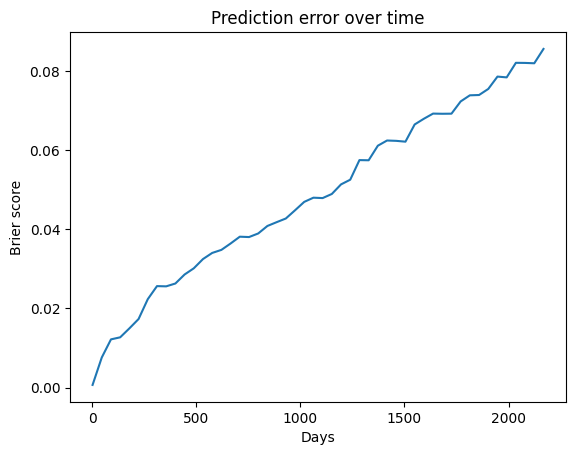

In [81]:
from sksurv.metrics import brier_score

times = np.linspace(
    1,
    np.percentile(y_test_surv["time"], 95),
    50
)

surv_matrix = get_survival_prob_matrix(
    coxph_final,
    X_test_scaled,
    times
)

_, brier_vals = brier_score(
    y_train_surv,
    y_test_surv,
    surv_matrix,
    times
)

plt.plot(times, brier_vals)
plt.xlabel("Days")
plt.ylabel("Brier score")
plt.title("Prediction error over time")
plt.show()

Calibration Curve (observed risk vs predicted risk)

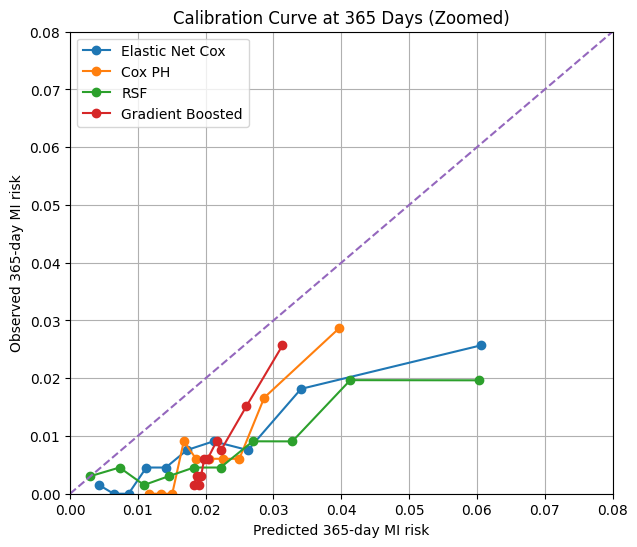

In [82]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

horizon = 365

y_binary = (
    (y_test_surv["event"] == True)
    &
    (y_test_surv["time"] <= horizon)
).astype(int)

def plot_calibration(model_name, surv_prob):
    risk = 1 - surv_prob

    frac_pos, mean_pred = calibration_curve(
        y_binary,
        risk,
        n_bins=10,
        strategy="quantile"
    )

    plt.plot(mean_pred, frac_pos, marker="o", label=model_name)

plt.figure(figsize=(7, 6))

plot_calibration("Elastic Net Cox", get_survival_prob_at_horizon(coxnet_final, X_test_scaled, horizon))
plot_calibration("Cox PH", get_survival_prob_at_horizon(coxph_final, X_test_scaled, horizon))
plot_calibration("RSF", get_survival_prob_at_horizon(rsf_final, X_test_imputed, horizon))
plot_calibration("Gradient Boosted", get_survival_prob_at_horizon(gbs_final, X_test_imputed, horizon))

plt.plot([0, 0.08], [0, 0.08], linestyle="--")
plt.xlim(0, 0.08)
plt.ylim(0, 0.08)

plt.xlabel("Predicted 365-day MI risk")
plt.ylabel("Observed 365-day MI risk")
plt.title("Calibration Curve at 365 Days (Zoomed)")
plt.legend()
plt.grid()
plt.show()

In [83]:
for name, model, Xuse in [
    ("Elastic Net Cox", coxnet_final, X_test_scaled),
    ("Cox PH", coxph_final, X_test_scaled),
    ("RSF", rsf_final, X_test_imputed),
    ("Gradient Boosted", gbs_final, X_test_imputed),
]:
    surv_prob = get_survival_prob_at_horizon(model, Xuse, horizon)
    risk = 1 - surv_prob
    print(name, "risk range:", risk.min(), risk.max(), "mean:", risk.mean())

Elastic Net Cox risk range: 0.0016895606078740633 0.23596876280551637 mean: 0.020399779523347983
Cox PH risk range: 0.008917674410067411 0.08102205402354434 mean: 0.0211799103249707
RSF risk range: 0.0 0.13076360363679063 mean: 0.023744888684609826
Gradient Boosted risk range: 0.016816950657299712 0.0683096942471092 mean: 0.02165193030719133


In [84]:
# Final summary table
final_metrics = pd.DataFrame({
    "Model": [
        "Cox PH",
        "Elastic Net",
        "RSF",
        "GBS"
    ],
    "C-index": [
        coxph_cindex,
        coxnet_cindex,
        rsf_cindex,
        gbs_cindex
    ],
    "AUC": [
        coxph_auc,
        coxnet_auc,
        rsf_auc,
        gbs_auc
    ],
    "Brier": [
        coxph_brier,
        coxnet_brier,
        rsf_brier,
        gbs_brier
    ]
})

display(final_metrics)

,Model,C-index,AUC,Brier
0,Cox PH,0.70,0.77,0.03
1,Elastic Net,0.70,0.78,0.03
2,RSF,0.70,0.77,0.03
3,GBS,0.69,0.74,0.03


### Kaplan Meier curves - risk stratified 

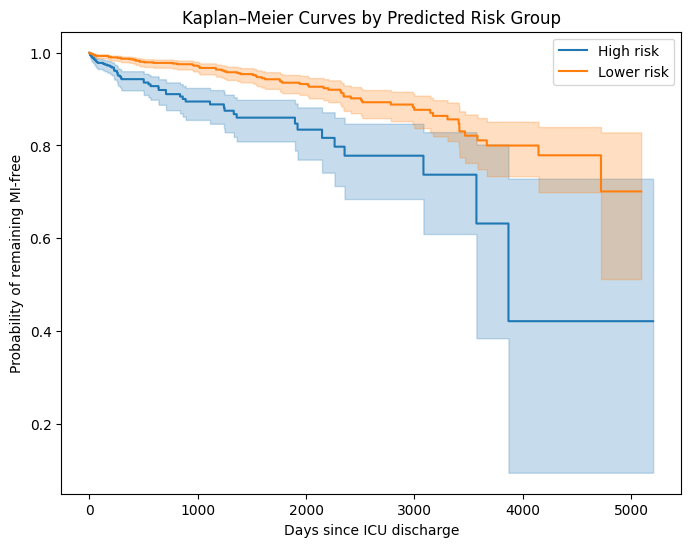

In [ ]:
# create risk groups 

risk_scores = coxnet_final.predict(X_test_scaled)

high_risk = risk_scores >= np.percentile(risk_scores, 75)
low_risk = risk_scores < np.percentile(risk_scores, 75)

from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))

# High risk
kmf.fit(
    y_test_surv["time"][high_risk],
    y_test_surv["event"][high_risk],
    label="High risk"
)
kmf.plot()

# Low risk
kmf.fit(
    y_test_surv["time"][low_risk],
    y_test_surv["event"][low_risk],
    label="Lower risk"
)
kmf.plot()

plt.xlabel("Days since ICU discharge")
plt.ylabel("Probability of remaining MI-free")
plt.title("Kaplan–Meier Curves by Predicted Risk Group")

plt.show()



In [95]:
from lifelines.statistics import logrank_test

results = logrank_test(
    y_test_surv["time"][high_risk],
    y_test_surv["time"][low_risk],
    event_observed_A=y_test_surv["event"][high_risk],
    event_observed_B=y_test_surv["event"][low_risk]
)

print(results.p_value)

6.395529302770732e-09


Subgroup performance by sex, age, and comorbidity burden

In [ ]:
from sksurv.metrics import cumulative_dynamic_auc
import numpy as np
import pandas as pd

# 1-year horizon
auc_time = np.array([365])

test_meta = df_consolidated.loc[X_test_scaled.index].copy()

def subgroup_auc_1yr(group_name, mask, risk_scores):
    mask = np.asarray(mask)

    n = mask.sum()
    events = y_test_surv["event"][mask].sum()

    auc, _ = cumulative_dynamic_auc(
        y_train_surv,
        y_test_surv[mask],
        risk_scores[mask],
        auc_time
    )

    return {
        "Subgroup": group_name,
        "N": n,
        "Events": int(events),
        "AUC–1 yr": auc[0]
    }

results = []

# Age
results.append(
    subgroup_auc_1yr(
        "Age < 65",
        test_meta["age"] < 65,
        coxnet_risk
    )
)

results.append(
    subgroup_auc_1yr(
        "Age ≥ 65",
        test_meta["age"] >= 65,
        coxnet_risk
    )
)

# Sex
results.append(
    subgroup_auc_1yr(
        "Female",
        test_meta["gender"] == "F",
        coxnet_risk
    )
)

results.append(
    subgroup_auc_1yr(
        "Male",
        test_meta["gender"] == "M",
        coxnet_risk
    )
)

# Comorbidity burden

results.append(
    subgroup_auc_1yr(
        "Charlson < 3",
        test_meta["charlson_comorbidity_index"] < 3,
        coxnet_risk
    )
)

results.append(
    subgroup_auc_1yr(
        "Charlson ≥ 3",
        test_meta["charlson_comorbidity_index"] >= 3,
        coxnet_risk
    )
)

subgroup_auc_table = pd.DataFrame(results)

subgroup_auc_table["AUC–1 yr"] = subgroup_auc_table["AUC–1 yr"].round(4)

display(subgroup_auc_table)

,Subgroup,N,Events,AUC–1 yr
0,Age < 65,3511,48,0.84
1,Age ≥ 65,3104,84,0.66
2,Female,2920,55,0.78
3,Male,3695,77,0.78
4,Charlson < 3,2467,23,0.70
5,Charlson ≥ 3,4148,109,0.69


In [ ]:
from sksurv.metrics import cumulative_dynamic_auc
from sklearn.utils import resample
import numpy as np
import pandas as pd

# 1-year horizon
auc_time = np.array([365])

# Metadata aligned to test set
test_meta = df_consolidated.loc[X_test_scaled.index].copy()


def bootstrap_subgroup_auc_1yr(group_name, mask, risk_scores, n_bootstrap=500):
    mask = np.asarray(mask)
    
    n = mask.sum()
    events = int(y_test_surv["event"][mask].sum())
    
    # Get subgroup data
    y_subgroup = y_test_surv[mask]
    risk_subgroup = risk_scores[mask]
    
    # Point estimate
    auc, _ = cumulative_dynamic_auc(
        y_train_surv,
        y_subgroup,
        risk_subgroup,
        auc_time
    )
    point_auc = auc[0]
    
    # Bootstrap
    bootstrap_aucs = []
    n_subgroup = len(risk_subgroup)
    
    for _ in range(n_bootstrap):
        idx = resample(np.arange(n_subgroup))
        try:
            auc_boot, _ = cumulative_dynamic_auc(
                y_train_surv,
                y_subgroup[idx],
                risk_subgroup[idx],
                auc_time
            )
            bootstrap_aucs.append(auc_boot[0])
        except:
            continue
    
    bootstrap_aucs = np.array(bootstrap_aucs)
    ci_lower, ci_upper = np.percentile(bootstrap_aucs, [2.5, 97.5])
    
    return {
        "Subgroup": group_name,
        "N": n,
        "Events": events,
        "AUC–1 yr": round(point_auc, 4),
        "Bootstrap Mean": round(np.mean(bootstrap_aucs), 4),
        "Bootstrap Std": round(np.std(bootstrap_aucs), 4),
        "95% CI Lower": round(ci_lower, 4),
        "95% CI Upper": round(ci_upper, 4),
    }


results = []

# Age
results.append(
    bootstrap_subgroup_auc_1yr(
        "Age < 65",
        test_meta["age"] < 65,
        coxnet_risk
    )
)

results.append(
    bootstrap_subgroup_auc_1yr(
        "Age ≥ 65",
        test_meta["age"] >= 65,
        coxnet_risk
    )
)

# Sex
results.append(
    bootstrap_subgroup_auc_1yr(
        "Female",
        test_meta["gender"] == "F",
        coxnet_risk
    )
)

results.append(
    bootstrap_subgroup_auc_1yr(
        "Male",
        test_meta["gender"] == "M",
        coxnet_risk
    )
)

# Comorbidity burden
results.append(
    bootstrap_subgroup_auc_1yr(
        "Charlson < 3",
        test_meta["charlson_comorbidity_index"] < 3,
        coxnet_risk
    )
)

results.append(
    bootstrap_subgroup_auc_1yr(
        "Charlson ≥ 3",
        test_meta["charlson_comorbidity_index"] >= 3,
        coxnet_risk
    )
)

subgroup_auc_table = pd.DataFrame(results)

display(subgroup_auc_table)

,Subgroup,N,Events,AUC–1 yr,Bootstrap Mean,Bootstrap Std,95% CI Lower,95% CI Upper
0,Age < 65,3511,48,0.84,0.84,0.05,0.72,0.91
1,Age ≥ 65,3104,84,0.66,0.66,0.05,0.57,0.75
2,Female,2920,55,0.78,0.78,0.04,0.70,0.85
3,Male,3695,77,0.78,0.78,0.04,0.69,0.86
4,Charlson < 3,2467,23,0.70,NaN,NaN,NaN,NaN
5,Charlson ≥ 3,4148,109,0.69,0.69,0.04,0.62,0.77


In [91]:
from sksurv.metrics import cumulative_dynamic_auc
from sklearn.utils import resample
import numpy as np

def bootstrap_auc_difference_pvalue(
    y_train,
    y_test_full,
    risk_scores_full,
    mask_a,
    mask_b,
    auc_time=np.array([365]),
    n_bootstrap=1000,
):
    """
    Bootstrap-based test for difference in AUC between two subgroups.
    Returns the observed difference, bootstrap CI for the difference,
    and a two-sided p-value.
    """
    mask_a = np.asarray(mask_a)
    mask_b = np.asarray(mask_b)
    
    # Get subgroup data
    y_a = y_test_full[mask_a]
    y_b = y_test_full[mask_b]
    risk_a = risk_scores_full[mask_a]
    risk_b = risk_scores_full[mask_b]
    
    # Observed AUCs
    auc_a, _ = cumulative_dynamic_auc(y_train, y_a, risk_a, auc_time)
    auc_b, _ = cumulative_dynamic_auc(y_train, y_b, risk_b, auc_time)
    observed_diff = auc_a[0] - auc_b[0]
    
    # Bootstrap differences
    n_a, n_b = len(risk_a), len(risk_b)
    diffs = []
    
    for _ in range(n_bootstrap):
        idx_a = resample(np.arange(n_a))
        idx_b = resample(np.arange(n_b))
        
        try:
            auc_a_boot, _ = cumulative_dynamic_auc(
                y_train, y_a[idx_a], risk_a[idx_a], auc_time
            )
            auc_b_boot, _ = cumulative_dynamic_auc(
                y_train, y_b[idx_b], risk_b[idx_b], auc_time
            )
            
            if not (np.isnan(auc_a_boot[0]) or np.isnan(auc_b_boot[0])):
                diffs.append(auc_a_boot[0] - auc_b_boot[0])
        except:
            continue
    
    diffs = np.array(diffs)
    
    # 95% CI for the difference
    ci_lower, ci_upper = np.percentile(diffs, [2.5, 97.5])
    
    # Two-sided p-value: proportion of bootstrap differences ≤ 0 if observed > 0
    # (or ≥ 0 if observed < 0), times 2
    if observed_diff > 0:
        p_value = 2 * np.mean(diffs <= 0)
    else:
        p_value = 2 * np.mean(diffs >= 0)
    
    p_value = min(p_value, 1.0)  # cap at 1
    
    return {
        "Observed AUC A": round(auc_a[0], 4),
        "Observed AUC B": round(auc_b[0], 4),
        "Observed Difference": round(observed_diff, 4),
        "95% CI for Difference": (round(ci_lower, 4), round(ci_upper, 4)),
        "p-value": round(p_value, 4),
    }


# Apply to your subgroups
test_meta = df_consolidated.loc[X_test_scaled.index].copy()

# Age comparison
print("=== Age: Under 65 vs 65+ ===")
age_result = bootstrap_auc_difference_pvalue(
    y_train_surv,
    y_test_surv,
    coxnet_risk,
    mask_a=test_meta["age"] < 65,
    mask_b=test_meta["age"] >= 65,
)
for k, v in age_result.items():
    print(f"  {k}: {v}")

# Sex comparison
print("\n=== Sex: Female vs Male ===")
sex_result = bootstrap_auc_difference_pvalue(
    y_train_surv,
    y_test_surv,
    coxnet_risk,
    mask_a=test_meta["gender"] == "F",
    mask_b=test_meta["gender"] == "M",
)
for k, v in sex_result.items():
    print(f"  {k}: {v}")

=== Age: Under 65 vs 65+ ===
  Observed AUC A: 0.8366
  Observed AUC B: 0.6646
  Observed Difference: 0.172
  95% CI for Difference: (0.0254, 0.2989)
  p-value: 0.032

=== Sex: Female vs Male ===
  Observed AUC A: 0.7759
  Observed AUC B: 0.7775
  Observed Difference: -0.0016
  95% CI for Difference: (-0.107, 0.1189)
  p-value: 0.988


In [92]:

df_consolidated["gender"].value_counts(dropna=False)

# compute subgroup counts/event rates
for g in df_consolidated["gender"].dropna().unique():
    mask = df_consolidated["gender"] == g
    
    n = mask.sum()
    events = df_consolidated.loc[mask, "event"].sum()
    event_rate = events / n
    
    print(g)
    print("N:", n)
    print("Events:", events)
    print("Event rate:", round(event_rate, 4))
    print()
# test set subgroup event rates
test_meta = df_consolidated.loc[X_test_scaled.index].copy()

for g in test_meta["gender"].dropna().unique():
    mask = test_meta["gender"] == g
    
    n = mask.sum()
    events = y_test_surv["event"][mask.values].sum()
    
    print(g)
    print("Test N:", n)
    print("Test events:", events)
    print("Test event rate:", round(events / n, 4))
    print()

M
N: 18563
Events: 399
Event rate: 0.0215

F
N: 14509
Events: 261
Event rate: 0.018

F
Test N: 2920
Test events: 55
Test event rate: 0.0188

M
Test N: 3695
Test events: 77
Test event rate: 0.0208



In [ ]:

# Sensitivity Analysis: Models restricted to followup_days > 0

# 55% of patients in cohort have followup_days == 0, meaning
# they were discharged from MIMIC and never returned. We retain them
# in the primary analysis as censored at day 1. This sensitivity
# analysis evaluates model performance restricted to patients with
# positive follow-up time to assess whether including zero-followup
# patients meaningfully affects discrimination estimates.

from sksurv.metrics import concordance_index_censored

# Get the followup status for test patients
test_meta = df_consolidated.loc[X_test_scaled.index].copy()
followup_mask_test = test_meta['followup_days'] > 0

print(f"Test set composition:")
print(f"  Total test patients:        {len(X_test_scaled):,}")
print(f"  With followup_days > 0:     {followup_mask_test.sum():,} ({100*followup_mask_test.mean():.1f}%)")
print(f"  With followup_days == 0:    {(~followup_mask_test).sum():,} ({100*(~followup_mask_test).mean():.1f}%)")
print()

# Event counts
n_events_full = y_test_surv["event"].sum()
n_events_followup = y_test_surv["event"][followup_mask_test.values].sum()
print(f"Events:")
print(f"  Full test set:              {n_events_full:,} ({100*n_events_full/len(y_test_surv):.2f}%)")
print(f"  Followup > 0 subset:        {n_events_followup:,} ({100*n_events_followup/followup_mask_test.sum():.2f}%)")
print()

print("="*70)
print("MODEL PERFORMANCE: Full Cohort vs Followup > 0 Subset")
print("="*70)

results = []
for model_name, risk in [
    ("Cox PH", coxph_risk),
    ("Elastic Net Cox", coxnet_risk),
    ("RSF", rsf_risk),
    ("Gradient Boosted", gbs_risk),
]:
    # Convert to numpy if pandas
    if hasattr(risk, 'values'):
        risk_arr = risk.values
    else:
        risk_arr = np.asarray(risk)
    
    # Full cohort C-index
    c_full = concordance_index_censored(
        y_test_surv["event"].astype(bool),
        y_test_surv["time"],
        risk_arr
    )[0]
    
    # Followup > 0 only C-index
    c_followup = concordance_index_censored(
        y_test_surv["event"][followup_mask_test.values].astype(bool),
        y_test_surv["time"][followup_mask_test.values],
        risk_arr[followup_mask_test.values]
    )[0]
    
    results.append({
        "Model": model_name,
        "C-index (Full Cohort)": round(c_full, 4),
        "C-index (Followup > 0)": round(c_followup, 4),
        "Difference": round(c_followup - c_full, 4),
    })

sensitivity_df = pd.DataFrame(results)
display(sensitivity_df)

Test set composition:
  Total test patients:        6,615
  With followup_days > 0:     3,079 (46.5%)
  With followup_days == 0:    3,536 (53.5%)

Events:
  Full test set:              132 (2.00%)
  Followup > 0 subset:        132 (4.29%)

MODEL PERFORMANCE: Full Cohort vs Followup > 0 Subset


,Model,C-index (Full Cohort),C-index (Followup > 0),Difference
0,Cox PH,0.70,0.70,0.01
1,Elastic Net Cox,0.70,0.70,0.00
2,RSF,0.70,0.70,-0.00
3,Gradient Boosted,0.69,0.68,-0.00
